# EDA preprocessing information

This notebook is to display raw merged dataset and see mising values, outliers, measurement errors, etc. It is not to be used for any data cleaning or preprocessing, just to get an idea of the data and its quality. Preprocessing will be done in `src/preprocessing` module. Next notebook will be used for cleaned data and EDA on it.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

In [2]:
pd.set_option("display.float_format", lambda x: f"{x:.2f}")
pd.set_option("display.precision", 2)

In [3]:
source_dir = Path("../data/processed/merged/merged_all_years.csv")

In [4]:
df = pd.read_csv(source_dir)
df.head()

,year,month,day,hour,day_of_week,holiday,before_holiday,consumption_gasnet,consumption_jmpnet,consumption_smpnet,...,wind_direction_10m,apparent_temperature,wind_gusts_10m,precipitation,snowfall,snow_depth,traded_volume_mwh,weighted_avg_price_eur_mwh,min_price_eur_mwh,max_price_eur_mwh
0,2013,1,1,0,1,1,0,309647.00,266965.00,165229.00,...,165.96,-3.64,17.64,0.00,0.00,0.00,0.00,NaN,NaN,NaN
1,2013,1,1,1,1,1,0,317580.00,268874.00,144587.00,...,164.74,-4.36,14.40,0.00,0.00,0.00,0.00,NaN,NaN,NaN
2,2013,1,1,2,1,1,0,306847.00,264634.00,159128.00,...,165.38,-5.12,13.32,0.00,0.00,0.00,0.00,NaN,NaN,NaN
3,2013,1,1,3,1,1,0,311308.00,258091.00,158021.00,...,169.11,-5.81,14.04,0.00,0.00,0.00,0.00,NaN,NaN,NaN
4,2013,1,1,4,1,1,0,313706.00,266043.00,158496.00,...,171.87,-6.28,14.04,0.00,0.00,0.00,0.00,NaN,NaN,NaN


# Overview

In [5]:
df.columns.tolist()

['year',
 'month',
 'day',
 'hour',
 'day_of_week',
 'holiday',
 'before_holiday',
 'consumption_gasnet',
 'consumption_jmpnet',
 'consumption_smpnet',
 'consumption_total',
 'consumption_vcpnet',
 'temperature_2m',
 'relative_humidity_2m',
 'pressure_msl',
 'surface_pressure',
 'dew_point_2m',
 'cloud_cover',
 'wind_speed_10m',
 'wind_direction_10m',
 'apparent_temperature',
 'wind_gusts_10m',
 'precipitation',
 'snowfall',
 'snow_depth',
 'traded_volume_mwh',
 'weighted_avg_price_eur_mwh',
 'min_price_eur_mwh',
 'max_price_eur_mwh']

In [6]:
len(df.columns)

29

In [7]:
WEATHER_VARIABLES = [
    "temperature_2m",
    "relative_humidity_2m",
    "pressure_msl",
    "surface_pressure",
    "dew_point_2m",
    "cloud_cover",
    "wind_speed_10m",
    "wind_direction_10m",
    "apparent_temperature",
    "wind_gusts_10m",
    "precipitation",
    "snowfall",
    "snow_depth",
]

DATETIME_VARIABLES = [
    "year",
    "month",
    "day",
    "hour",
    "day_of_week",
    "holiday",
    "before_holiday",
]

CONSUMPTION_VARIABLES = [
    "consumption_gasnet",
    "consumption_jmpnet",
    "consumption_smpnet",
    "consumption_total",
    "consumption_vcpnet",
]

PRICE_VARIABLES = [
    "traded_volume_mwh",
    "weighted_avg_price_eur_mwh",
    "min_price_eur_mwh",
    "max_price_eur_mwh",
]

- **WEATHER_VARIABLES** 
    - Weather variables will probably have missing values. Negative, zero or extreme values are highly possible.
- **CONSUMPTION_VARIABLES**
    - Consumption variables will probably have missing values and zero values. Negative values must be dealed with, as they are not possible. Extreme values are also possible.
- **PRICE_VARIABLES**
    - Price variables will probably have missing values and zero values. Negative values must be dealed with, as they are not possible. Extreme values are also possible.
    - Importnat note: since source for price variables is one value for day replicated for each hour 24 times, we need to be careful with replacing and computing those values.
- **TIME_VARIABLES**
    - These are automatically generated variables, so they should not have any missing values or outliers. They are declared because we can exclude them from some analysis.

## Missing values

In [8]:
nan_list = []
for label, cols in [
    ("Consumption", CONSUMPTION_VARIABLES),
    ("Weather", WEATHER_VARIABLES),
    ("Price", PRICE_VARIABLES),
]:
    for col in cols:
        nan_list.append(
            {
                "Category": label,
                "Column": col,
                "NaN_Count": df[col].isna().sum(),
            }
        )

nan_df = pd.DataFrame(nan_list)

for cat, sub in nan_df.groupby("Category"):
    print(cat)
    display(sub)
    print()
    print(f"Total NaN in {cat}: {sub['NaN_Count'].sum()}")
    print("-" * 40)

Consumption


,Category,Column,NaN_Count
0,Consumption,consumption_gasnet,114
1,Consumption,consumption_jmpnet,55
2,Consumption,consumption_smpnet,39
3,Consumption,consumption_total,32
4,Consumption,consumption_vcpnet,53



Total NaN in Consumption: 293
----------------------------------------
Price


,Category,Column,NaN_Count
18,Price,traded_volume_mwh,312
19,Price,weighted_avg_price_eur_mwh,1728
20,Price,min_price_eur_mwh,1728
21,Price,max_price_eur_mwh,1728



Total NaN in Price: 5496
----------------------------------------
Weather


,Category,Column,NaN_Count
5,Weather,temperature_2m,13
6,Weather,relative_humidity_2m,13
7,Weather,pressure_msl,13
8,Weather,surface_pressure,13
9,Weather,dew_point_2m,13
10,Weather,cloud_cover,13
11,Weather,wind_speed_10m,13
12,Weather,wind_direction_10m,13
13,Weather,apparent_temperature,13
14,Weather,wind_gusts_10m,13



Total NaN in Weather: 169
----------------------------------------


## Negative values

In [9]:
neg_list = []
for label, cols in [
    ("Consumption", CONSUMPTION_VARIABLES),
    ("Weather", WEATHER_VARIABLES),
    ("Price", PRICE_VARIABLES),
]:
    for col in cols:
        neg_list.append(
            {"Category": label, "Column": col, "Negative_Count": (df[col] < 0).sum()}
        )

neg_df = pd.DataFrame(neg_list)
neg_df = neg_df[neg_df["Negative_Count"] > 0].sort_values(
    "Negative_Count", ascending=False
)

for cat, sub in neg_df.groupby("Category"):
    print(f"{cat}")
    display(sub)
    print()

Consumption


,Category,Column,Negative_Count
1,Consumption,consumption_jmpnet,12
3,Consumption,consumption_total,5
0,Consumption,consumption_gasnet,1
2,Consumption,consumption_smpnet,1
4,Consumption,consumption_vcpnet,1



Weather


,Category,Column,Negative_Count
13,Weather,apparent_temperature,27750
9,Weather,dew_point_2m,26034
5,Weather,temperature_2m,11487


## Zero values

In [10]:
zero_list = []
for label, cols in [
    ("Consumption", CONSUMPTION_VARIABLES),
    ("Weather", WEATHER_VARIABLES),
    ("Price", PRICE_VARIABLES),
]:
    for col in cols:
        zero_list.append(
            {"Category": label, "Column": col, "Zero_Count": (df[col] == 0).sum()}
        )

zero_df = pd.DataFrame(zero_list)
zero_df = zero_df[zero_df["Zero_Count"] > 0].sort_values("Zero_Count", ascending=False)

for cat, sub in zero_df.groupby("Category"):
    print(cat)
    display(sub)
    print()

Consumption


,Category,Column,Zero_Count
0,Consumption,consumption_gasnet,43
4,Consumption,consumption_vcpnet,17
1,Consumption,consumption_jmpnet,15
2,Consumption,consumption_smpnet,15
3,Consumption,consumption_total,4



Price


,Category,Column,Zero_Count
18,Price,traded_volume_mwh,1416



Weather


,Category,Column,Zero_Count
16,Weather,snowfall,111766
17,Weather,snow_depth,99341
15,Weather,precipitation,97257
10,Weather,cloud_cover,9453
9,Weather,dew_point_2m,183
5,Weather,temperature_2m,127
11,Weather,wind_speed_10m,34


## Extreme outliers

#### Whole timeline

In [11]:
BASE_COLUMNS = [
    "consumption_total",
    "consumption_gasnet",
    "consumption_jmpnet",
    "consumption_smpnet",
    "consumption_vcpnet",
    *WEATHER_VARIABLES,
    *PRICE_VARIABLES,
]

timestamp_candidates = ["date_time", "datetime", "timestamp", "date", "time"]
timestamp_col = next((col for col in timestamp_candidates if col in df.columns), None)

df_eda = df.copy()
if timestamp_col is None and {"year", "month", "day", "hour"}.issubset(df_eda.columns):
    df_eda["timestamp"] = pd.to_datetime(
        df_eda[["year", "month", "day", "hour"]].rename(columns={"hour": "hour"}),
        errors="coerce",
    )
    timestamp_col = "timestamp"
elif timestamp_col is not None:
    df_eda[timestamp_col] = pd.to_datetime(df_eda[timestamp_col], errors="coerce")
else:
    raise ValueError(
        f"No timestamp data found. Need one of {timestamp_candidates} or columns year/month/day/hour. Available: {df.columns.tolist()}"
    )

df_eda = (
    df_eda.dropna(subset=[timestamp_col])
    .sort_values(timestamp_col)
    .reset_index(drop=True)
)
df_eda["date"] = df_eda[timestamp_col].dt.floor("D")
df_eda["month_period"] = df_eda[timestamp_col].dt.to_period("M").astype(str)
df_eda["hour"] = df_eda[timestamp_col].dt.hour
df_eda["month"] = df_eda[timestamp_col].dt.month

war_start = pd.Timestamp("2022-02-24")
df_eda["period"] = np.where(
    df_eda[timestamp_col] < war_start, "pre_conflict", "post_conflict"
)

In [12]:
def mad_zscore(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    med = s.median()
    mad = (s - med).abs().median()
    if pd.isna(mad) or mad == 0:
        return pd.Series(np.nan, index=s.index)
    return 0.6745 * (s - med) / mad


def rolling_robust_flag(
    series: pd.Series, window: int, threshold: float = 5.0
) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    rolling_med = s.rolling(
        window=window, center=True, min_periods=max(6, window // 4)
    ).median()
    residual = s - rolling_med
    rolling_mad = (
        residual.abs()
        .rolling(window=window, center=True, min_periods=max(6, window // 4))
        .median()
    )
    robust_scale = (rolling_mad * 1.4826).replace(0, np.nan)
    score = residual / robust_scale
    return score.abs() > threshold


def top_flagged_rows(
    data: pd.DataFrame, col: str, flag_col: str, n: int = 10
) -> pd.DataFrame:
    subset = data.loc[data[flag_col], [timestamp_col, col, "period"]].copy()
    if subset.empty:
        return subset
    subset["abs_value"] = subset[col].abs()
    return (
        subset.sort_values("abs_value", ascending=False)
        .head(n)
        .drop(columns="abs_value")
    )


def summary_from_flags(
    data: pd.DataFrame, cols: list[str], flag_suffix: str
) -> pd.DataFrame:
    rows = []
    for col in cols:
        flag_col = f"{col}_{flag_suffix}"
        if flag_col not in data.columns:
            continue
        total = data[col].notna().sum()
        flagged = int(data[flag_col].sum())
        rows.append(
            {
                "Column": col,
                "Rows": int(total),
                "Flagged": flagged,
                "Flagged_%": round(100 * flagged / total, 3) if total else np.nan,
            }
        )
    return (
        pd.DataFrame(rows).sort_values("Flagged", ascending=False)
        if rows
        else pd.DataFrame()
    )


OUTLIER_CFG = {
    "global_mad_threshold": 4.5,
    "rolling_threshold": 4.0,
    "yoy_mad_threshold": 4.5,
    "price_mad_threshold": 4.5,
    "weather_quantile_low": 0.01,
    "weather_quantile_high": 0.99,
}

print("Prepared df_eda and helper functions.")
print(
    f"Rows: {len(df_eda):,}, period split: {(df_eda['period'] == 'pre_conflict').sum():,} pre / {(df_eda['period'] == 'post_conflict').sum():,} post"
)

Prepared df_eda and helper functions.
Rows: 113,952, period split: 80,184 pre / 33,768 post


#### Before and after conflict

,Group,Column,Period,Flagged,Rows,Flagged_%
4,Consumption,consumption_smpnet,post_conflict,1,33768,0.00
0,Consumption,consumption_gasnet,post_conflict,0,33768,0.00
2,Consumption,consumption_jmpnet,post_conflict,0,33768,0.00
6,Consumption,consumption_vcpnet,post_conflict,0,33768,0.00
1,Consumption,consumption_gasnet,pre_conflict,12,80184,0.01
3,Consumption,consumption_jmpnet,pre_conflict,7,80184,0.01
5,Consumption,consumption_smpnet,pre_conflict,4,80184,0.01
7,Consumption,consumption_vcpnet,pre_conflict,2,80184,0.00
40,Price,max_price_eur_mwh,post_conflict,5592,33768,16.56
36,Price,weighted_avg_price_eur_mwh,post_conflict,5304,33768,15.71


,month_period,period,flag_rate,Group
0,2013-01-01,pre_conflict,0.00,Consumption
1,2013-02-01,pre_conflict,0.00,Consumption
2,2013-03-01,pre_conflict,0.00,Consumption
3,2013-04-01,pre_conflict,0.00,Consumption
4,2013-05-01,pre_conflict,0.00,Consumption


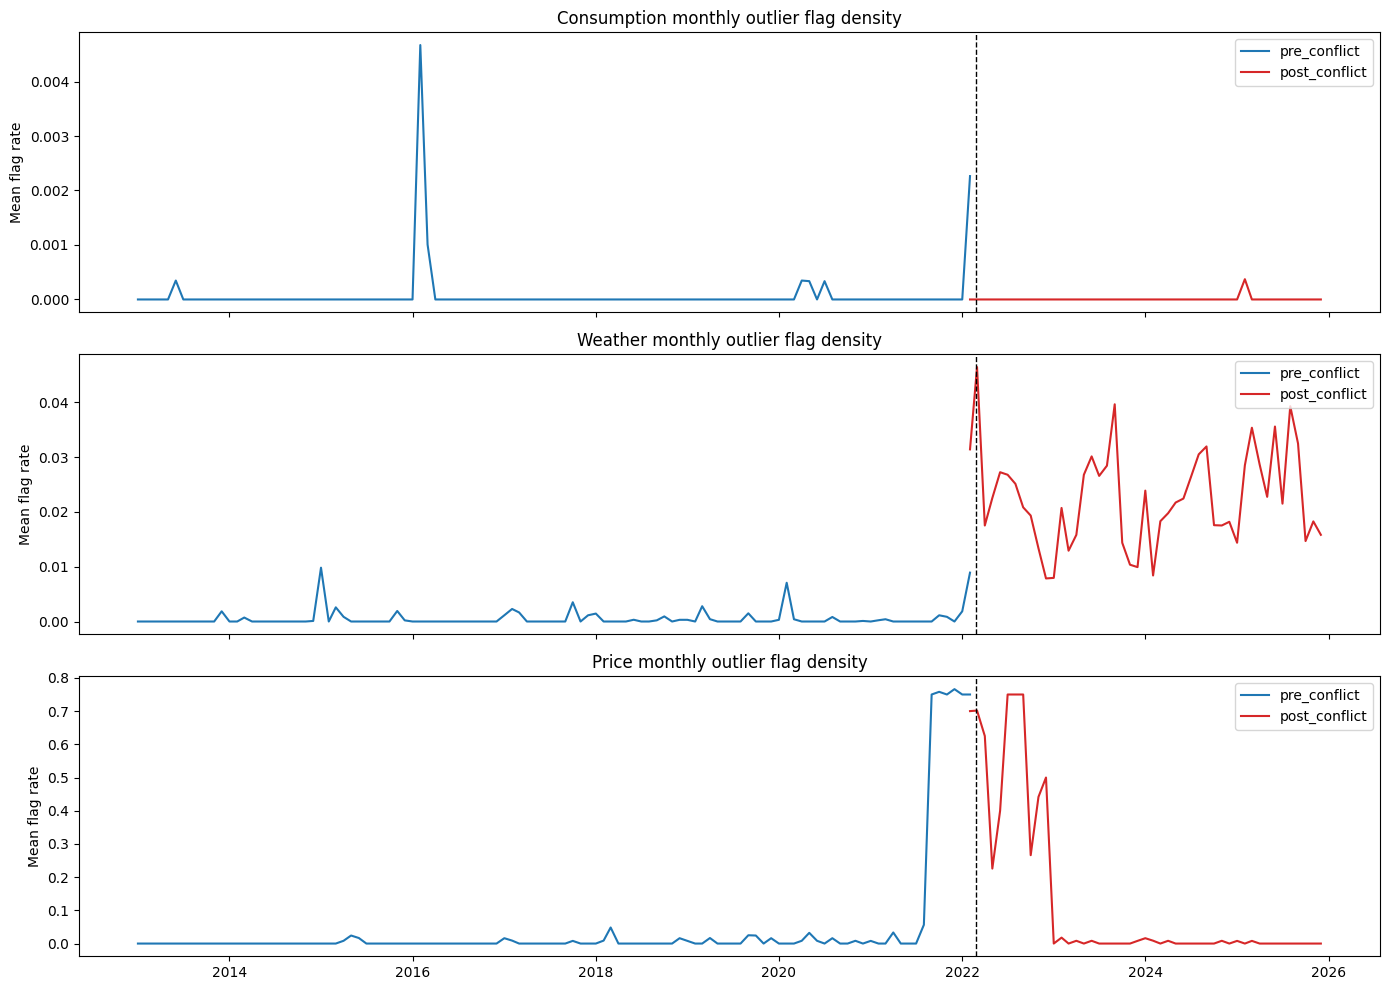

In [13]:
consumption_outlier_cols = [
    col
    for col in CONSUMPTION_VARIABLES
    if col != "consumption_total" and col in df_eda.columns
]
overview_cols = list(
    dict.fromkeys([*consumption_outlier_cols, *WEATHER_VARIABLES, *PRICE_VARIABLES])
)

for col in overview_cols:
    if col not in df_eda.columns:
        continue
    z_col = f"{col}_flag_global_mad"
    df_eda[z_col] = False
    for _, idx in df_eda.groupby("period").groups.items():
        z = mad_zscore(df_eda.loc[idx, col])
        df_eda.loc[idx, z_col] = z.abs() > OUTLIER_CFG["global_mad_threshold"]

group_map = {}
for col in consumption_outlier_cols:
    group_map[col] = "Consumption"
for col in WEATHER_VARIABLES:
    group_map[col] = "Weather"
for col in PRICE_VARIABLES:
    group_map[col] = "Price"

records = []
for col, grp in group_map.items():
    flag_col = f"{col}_flag_global_mad"
    if flag_col not in df_eda.columns:
        continue
    by_period = df_eda.groupby("period")[flag_col].agg(["sum", "count"]).reset_index()
    for _, row in by_period.iterrows():
        records.append(
            {
                "Group": grp,
                "Column": col,
                "Period": row["period"],
                "Flagged": int(row["sum"]),
                "Rows": int(row["count"]),
                "Flagged_%": (
                    round(100 * row["sum"] / row["count"], 3)
                    if row["count"]
                    else np.nan
                ),
            }
        )

overview_df = pd.DataFrame(records).sort_values(
    ["Group", "Period", "Flagged"], ascending=[True, True, False]
)
display(overview_df)

monthly_group = []
for grp, cols in [
    ("Consumption", consumption_outlier_cols),
    ("Weather", WEATHER_VARIABLES),
    ("Price", PRICE_VARIABLES),
]:
    available_flags = [
        f"{c}_flag_global_mad" for c in cols if f"{c}_flag_global_mad" in df_eda.columns
    ]
    if not available_flags:
        continue
    temp = df_eda[["month_period", "period", *available_flags]].copy()
    temp["flag_rate"] = temp[available_flags].mean(axis=1)
    aggr = temp.groupby(["month_period", "period"], as_index=False)["flag_rate"].mean()
    aggr["Group"] = grp
    monthly_group.append(aggr)

if monthly_group:
    monthly_group_df = pd.concat(monthly_group, ignore_index=True)
    monthly_group_df["month_period"] = pd.to_datetime(
        monthly_group_df["month_period"] + "-01"
    )
    display(monthly_group_df.head())

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    for ax, grp in zip(axes, ["Consumption", "Weather", "Price"], strict=False):
        sub = monthly_group_df[monthly_group_df["Group"] == grp].sort_values(
            "month_period"
        )
        if sub.empty:
            ax.set_visible(False)
            continue
        for p, color in [("pre_conflict", "tab:blue"), ("post_conflict", "tab:red")]:
            part = sub[sub["period"] == p]
            ax.plot(
                part["month_period"],
                part["flag_rate"],
                label=p,
                color=color,
                linewidth=1.5,
            )
        ax.axvline(war_start, color="black", linestyle="--", linewidth=1)
        ax.set_title(f"{grp} monthly outlier flag density")
        ax.set_ylabel("Mean flag rate")
        ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

# Closer look

## Price variables integrity check

In [14]:
PRICE_TRIPLE = [
    "weighted_avg_price_eur_mwh",
    "min_price_eur_mwh",
    "max_price_eur_mwh",
]

missing_cols = [c for c in PRICE_TRIPLE if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required price columns: {missing_cols}")

price_check = df[PRICE_TRIPLE].copy()
valid_triplet_mask = price_check.notna().all(axis=1)
min_gt_max_mask = valid_triplet_mask & (
    price_check["min_price_eur_mwh"] > price_check["max_price_eur_mwh"]
)
outside_bounds_mask = valid_triplet_mask & (
    (price_check["weighted_avg_price_eur_mwh"] < price_check["min_price_eur_mwh"])
    | (price_check["weighted_avg_price_eur_mwh"] > price_check["max_price_eur_mwh"])
)
violations_mask = min_gt_max_mask | outside_bounds_mask

summary_df = pd.DataFrame(
    [
        {
            "Metric": "Rows total",
            "Value": int(len(df)),
        },
        {
            "Metric": "Rows with full price triplet",
            "Value": int(valid_triplet_mask.sum()),
        },
        {
            "Metric": "Rows with missing in triplet",
            "Value": int((~valid_triplet_mask).sum()),
        },
        {
            "Metric": "Rows where min > max",
            "Value": int(min_gt_max_mask.sum()),
        },
        {
            "Metric": "Rows where weighted_avg outside [min, max]",
            "Value": int(outside_bounds_mask.sum()),
        },
        {
            "Metric": "Rows violating min <= weighted_avg <= max",
            "Value": int(violations_mask.sum()),
        },
    ]
)
display(summary_df)

if violations_mask.any():
    ts_candidates = ["date_time", "datetime", "timestamp", "date", "time"]
    ts_col = next((c for c in ts_candidates if c in df.columns), None)

    cols_to_show = [
        c
        for c in [
            ts_col,
            "weighted_avg_price_eur_mwh",
            "min_price_eur_mwh",
            "max_price_eur_mwh",
        ]
        if c is not None and c in df.columns
    ]

    violations_df = df.loc[violations_mask, cols_to_show].copy()
    violations_df["violation_type"] = "weighted_avg_outside_bounds"
    violations_df.loc[min_gt_max_mask[violations_mask].values, "violation_type"] = (
        "min_gt_max"
    )

    print(f"Found {violations_df.shape[0]:,} violating rows.")
    display(violations_df.head(25))
else:
    print(
        "No violations found for min <= weighted_avg <= max (on non-missing triplets)."
    )

,Metric,Value
0,Rows total,113952
1,Rows with full price triplet,112224
2,Rows with missing in triplet,1728
3,Rows where min > max,0
4,"Rows where weighted_avg outside [min, max]",0
5,Rows violating min <= weighted_avg <= max,0


No violations found for min <= weighted_avg <= max (on non-missing triplets).


## Missing values

**NaN** values will be always calculated. Should be calculated as last because we will replace some values with NaN and we want to see how many missing values we have before and after that.

## Negative values

### Consumption

In [15]:
for col in CONSUMPTION_VARIABLES:
    neg_count = (df[col] < 0).sum()
    print(f"{col}: {neg_count}")

consumption_gasnet: 1
consumption_jmpnet: 12
consumption_smpnet: 1
consumption_total: 5
consumption_vcpnet: 1


How can be consumption negative? It cannot. We have to investigate this further.

In [16]:
for col in CONSUMPTION_VARIABLES:
    neg_rows = df.loc[df[col] < 0, [col]]
    if not neg_rows.empty:
        print(f"Negative values in {col}:")
        display(neg_rows)
        print()

Negative values in consumption_gasnet:


,consumption_gasnet
27596,-91659614.00



Negative values in consumption_jmpnet:


,consumption_jmpnet
27596,-155111263.00
27953,-221.00
27954,-244.00
27955,-314.00
27956,-337.00
27959,-319.00
27960,-274.00
27961,-203.00
27962,-153.00
27963,-127.00



Negative values in consumption_smpnet:


,consumption_smpnet
85898,-18321.00



Negative values in consumption_total:


,consumption_total
27596,-245982172.00
27953,-5.00
27954,-2.00
27955,-3.00
27956,-1.00



Negative values in consumption_vcpnet:


,consumption_vcpnet
23001,-4619.00


These are either too low for them to be negated or over the top. All those can be dropped. *VCP* looks like it was written as negative but it's only value, so it can be dropped as well for easier data handling.

### Weather

In [17]:
for col in WEATHER_VARIABLES:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        print(f"{col}: {neg_count}")

temperature_2m: 11487
dew_point_2m: 26034
apparent_temperature: 27750


Looks about right, only negative values are for temperature, which can be negative.

### Price

In [18]:
for col in PRICE_VARIABLES:
    neg_count = (df[col] < 0).sum()
    print(f"{col}: {neg_count}")

traded_volume_mwh: 0
weighted_avg_price_eur_mwh: 0
min_price_eur_mwh: 0
max_price_eur_mwh: 0


No negative values for price, which is good.

## Zero values

### Consumption

In [19]:
for col in CONSUMPTION_VARIABLES:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count}")

consumption_gasnet: 43
consumption_jmpnet: 15
consumption_smpnet: 15
consumption_total: 4
consumption_vcpnet: 17


Consumption is highly unlikely to be zero, so those values can be dropped.

### Weather

In [20]:
for col in WEATHER_VARIABLES:
    zero_count = (df[col] == 0).sum()
    if zero_count > 0:
        print(f"{col}: {zero_count}")

temperature_2m: 127
dew_point_2m: 183
cloud_cover: 9453
wind_speed_10m: 34
precipitation: 97257
snowfall: 111766
snow_depth: 99341


All those can be zero, so they can be kept.

### Price

In [21]:
for col in PRICE_VARIABLES:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count}")

traded_volume_mwh: 1416
weighted_avg_price_eur_mwh: 0
min_price_eur_mwh: 0
max_price_eur_mwh: 0


Only *traded_volume_mwh* has zero values, which is highly unlikely, so those values can be dropped.

## Outliers

### Before conflict

#### Consumption

consumption_gasnet (pre-conflict)
Value range: min=-91,659,614.00, max=2,000,187,846.00 | P01/P50/P99=129,404.21 / 295,511.00 / 642,176.58


,Column,Rows,Flagged,Flagged_%
0,consumption_gasnet,80070,422,0.53


,timestamp,consumption_gasnet,period
27587,2016-02-24 11:00:00,2000187846.00,pre_conflict
27925,2016-03-09 13:00:00,1705450767.00,pre_conflict
80012,2022-02-16 20:00:00,1000432665.00,pre_conflict
80011,2022-02-16 19:00:00,1000429371.00,pre_conflict
80006,2022-02-16 14:00:00,1000424694.00,pre_conflict
27590,2016-02-24 14:00:00,1000298543.00,pre_conflict
64525,2020-05-12 13:00:00,1000247826.00,pre_conflict
80003,2022-02-16 11:00:00,877713598.00,pre_conflict
80009,2022-02-16 17:00:00,865674101.00,pre_conflict
27596,2016-02-24 20:00:00,-91659614.00,pre_conflict


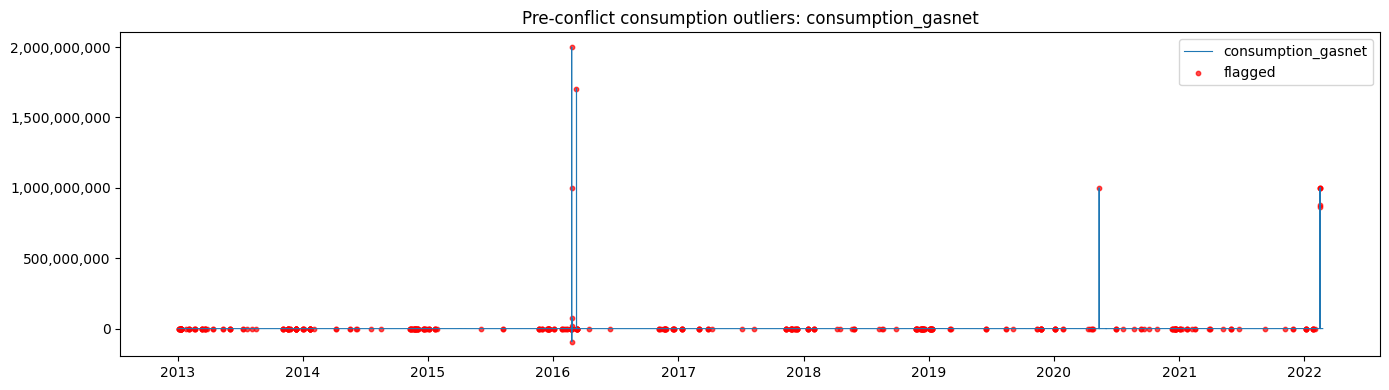

consumption_jmpnet (pre-conflict)
Value range: min=-155,111,263.00, max=45,176,675.00 | P01/P50/P99=29,752.80 / 164,158.00 / 488,568.44


,Column,Rows,Flagged,Flagged_%
1,consumption_jmpnet,80129,548,0.68


,timestamp,consumption_jmpnet,period
27596,2016-02-24 20:00:00,-155111263.00,pre_conflict
27597,2016-02-24 21:00:00,45176675.00,pre_conflict
27601,2016-02-25 01:00:00,44980282.00,pre_conflict
27600,2016-02-25 00:00:00,22836979.00,pre_conflict
27598,2016-02-24 22:00:00,22693489.00,pre_conflict
27602,2016-02-25 02:00:00,22363443.00,pre_conflict
4134,2013-06-22 06:00:00,1293786.00,pre_conflict
79962,2022-02-14 18:00:00,691011.00,pre_conflict
1879,2013-03-20 07:00:00,461225.00,pre_conflict
27631,2016-02-26 07:00:00,447737.00,pre_conflict


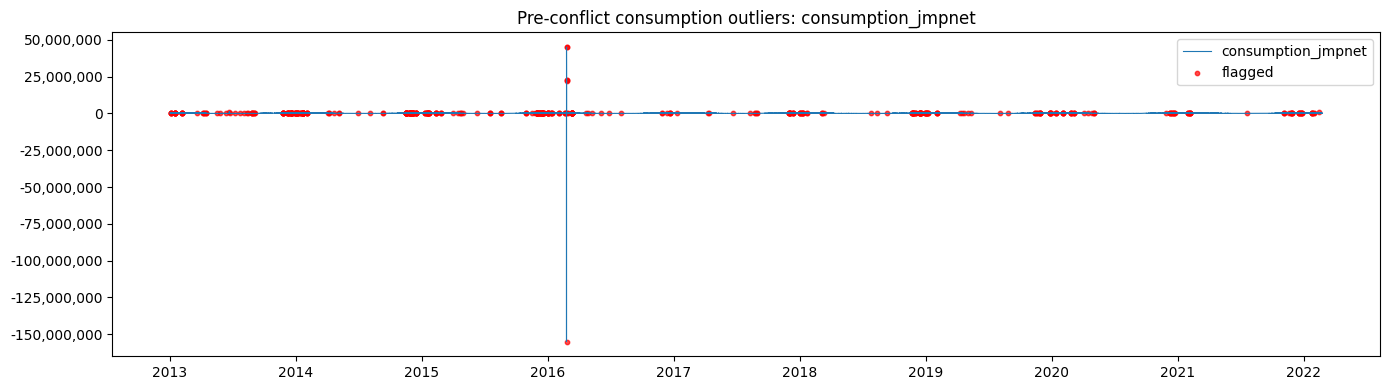

consumption_smpnet (pre-conflict)
Value range: min=0.00, max=1,000,285,509.00 | P01/P50/P99=54,048.20 / 142,949.00 / 349,434.92


,Column,Rows,Flagged,Flagged_%
2,consumption_smpnet,80145,248,0.31


,timestamp,consumption_smpnet,period
27609,2016-02-25 09:00:00,1000285509.00,pre_conflict
66030,2020-07-14 06:00:00,999910060.00,pre_conflict
63604,2020-04-04 04:00:00,900159335.00,pre_conflict
27969,2016-03-11 09:00:00,2563631.00,pre_conflict
27930,2016-03-09 18:00:00,476589.00,pre_conflict
27596,2016-02-24 20:00:00,467279.00,pre_conflict
18320,2015-02-03 08:00:00,395698.00,pre_conflict
824,2013-02-04 08:00:00,359978.00,pre_conflict
13525,2014-07-18 13:00:00,359938.00,pre_conflict
32982,2016-10-06 06:00:00,357383.00,pre_conflict


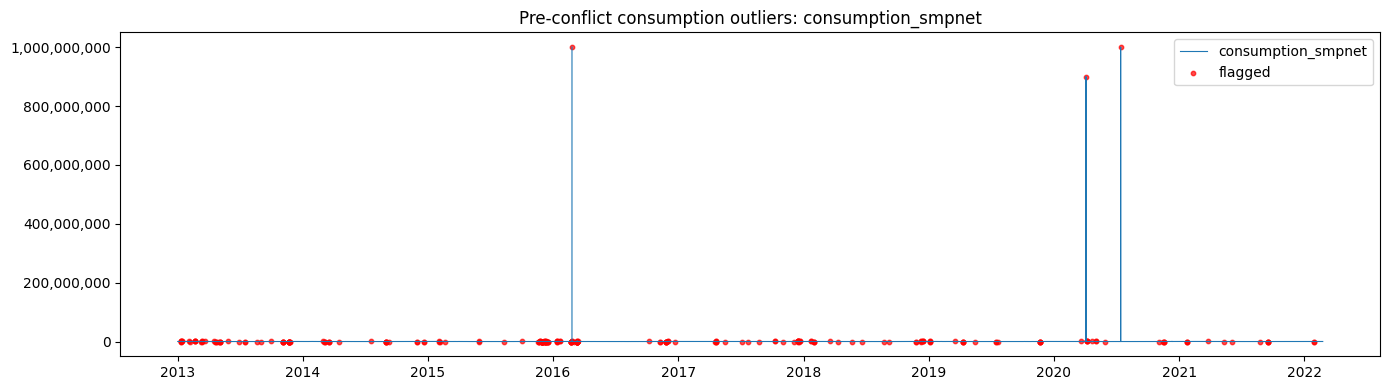

consumption_vcpnet (pre-conflict)
Value range: min=-4,619.00, max=1,494,351.00 | P01/P50/P99=24,541.30 / 82,646.00 / 237,190.10


,Column,Rows,Flagged,Flagged_%
3,consumption_vcpnet,80131,225,0.28


,timestamp,consumption_vcpnet,period
27969,2016-03-11 09:00:00,1494351.00,pre_conflict
27566,2016-02-23 14:00:00,410001.00,pre_conflict
27596,2016-02-24 20:00:00,321426.00,pre_conflict
52905,2019-01-14 09:00:00,295679.00,pre_conflict
27587,2016-02-24 11:00:00,267429.00,pre_conflict
33826,2016-11-10 10:00:00,262497.00,pre_conflict
922,2013-02-08 10:00:00,257673.00,pre_conflict
2335,2013-04-08 07:00:00,243060.00,pre_conflict
1400,2013-02-28 08:00:00,230031.00,pre_conflict
54272,2019-03-12 08:00:00,225158.00,pre_conflict


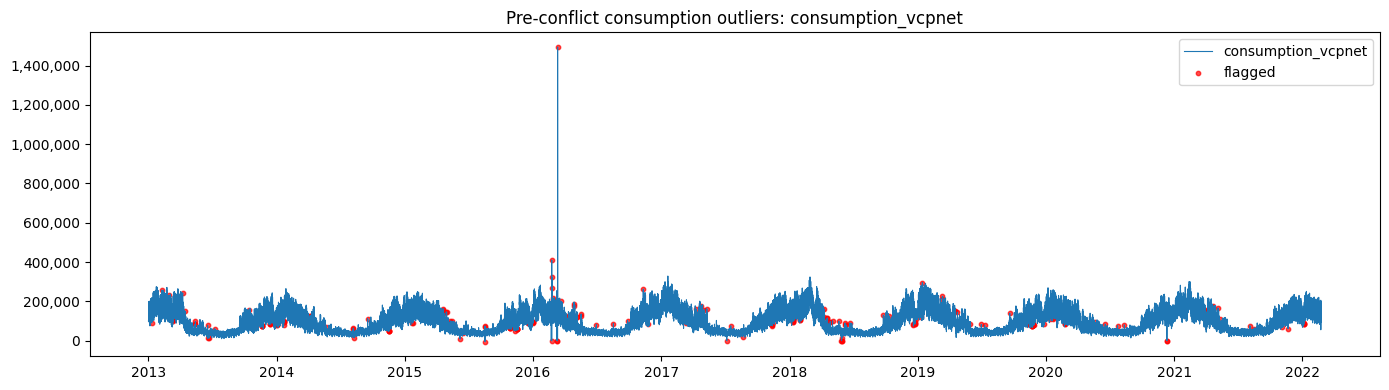

In [22]:
pre_df = df_eda[df_eda["period"] == "pre_conflict"].copy()
consumption_cols = [
    col
    for col in CONSUMPTION_VARIABLES
    if col != "consumption_total" and col in pre_df.columns
]

for col in consumption_cols:
    pre_df[f"{col}_flag_roll24"] = rolling_robust_flag(
        pre_df[col], window=24, threshold=OUTLIER_CFG["rolling_threshold"]
    )
    pre_df[f"{col}_flag_roll168"] = rolling_robust_flag(
        pre_df[col], window=168, threshold=OUTLIER_CFG["rolling_threshold"]
    )
    pre_df[f"{col}_flag_cons"] = pre_df[f"{col}_flag_roll24"].fillna(False) | pre_df[
        f"{col}_flag_roll168"
    ].fillna(False)

summary_pre_cons = summary_from_flags(pre_df, consumption_cols, "flag_cons")

for col in consumption_cols:
    flag_col = f"{col}_flag_cons"
    series = pd.to_numeric(pre_df[col], errors="coerce")
    q01 = series.quantile(0.01)
    q50 = series.quantile(0.50)
    q99 = series.quantile(0.99)

    print(f"{col} (pre-conflict)")
    print(
        f"Value range: min={series.min():,.2f}, max={series.max():,.2f} | "
        f"P01/P50/P99={q01:,.2f} / {q50:,.2f} / {q99:,.2f}"
    )
    display(summary_pre_cons[summary_pre_cons["Column"] == col])
    display(top_flagged_rows(pre_df, col, flag_col, n=15))

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(pre_df[timestamp_col], pre_df[col], linewidth=0.8, label=col)
    flagged = pre_df[pre_df[flag_col]]
    ax.scatter(
        flagged[timestamp_col],
        flagged[col],
        s=10,
        color="red",
        alpha=0.7,
        label="flagged",
    )
    ax.ticklabel_format(style="plain", axis="y", useOffset=False)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:,.0f}"))
    ax.set_title(f"Pre-conflict consumption outliers: {col}")
    ax.legend()
    plt.tight_layout()
    plt.show()

- **GASnet** before war the earliest not outlier value is *644 837* at date *2021-01-08 10:00*, which is possibly flagged due to the rolling window.
- **JMPnet** before war the earliest not outlier value is *691 011* at date *2022-02-14 18:00* which is possible due to the later values being higher too.
- **SMPnet** before war the earliest not outlier value is *476 589* at date *2016-03-09 18:00:00*, which is completely normal, I don't know why it is flagged as outlier since its surrounded by values around same level.
- **VCPnet** before war the earliest not outlier value is *410 001* at date *2016-02-23 14:00:00*, due to the one zero value before.

#### Weather variables

temperature_2m (pre-conflict)


,Column,Rows,Flagged,Flagged_%
0,temperature_2m,80175,1142,1.42


,timestamp,temperature_2m,period
56824,2019-06-26 16:00:00,38.00,pre_conflict
56921,2019-06-30 17:00:00,37.55,pre_conflict
56823,2019-06-26 15:00:00,37.40,pre_conflict
56825,2019-06-26 17:00:00,37.40,pre_conflict
56920,2019-06-30 16:00:00,37.35,pre_conflict
56922,2019-06-30 18:00:00,37.05,pre_conflict
56919,2019-06-30 15:00:00,36.75,pre_conflict
56923,2019-06-30 19:00:00,36.35,pre_conflict


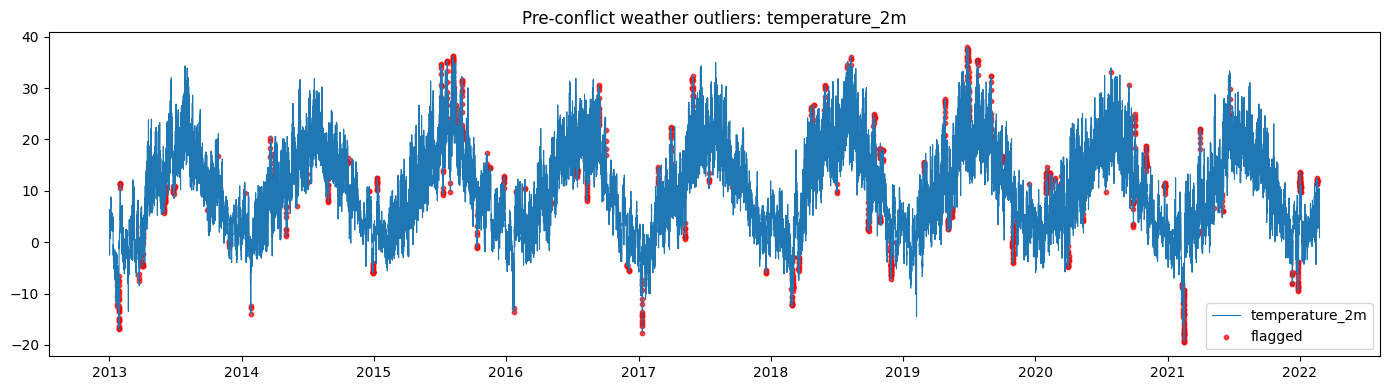

relative_humidity_2m (pre-conflict)


,Column,Rows,Flagged,Flagged_%
1,relative_humidity_2m,80175,1144,1.43


,timestamp,relative_humidity_2m,period
61005,2019-12-17 21:00:00,100.00,pre_conflict
59643,2019-10-22 03:00:00,100.00,pre_conflict
61010,2019-12-18 02:00:00,100.00,pre_conflict
61030,2019-12-18 22:00:00,100.00,pre_conflict
61031,2019-12-18 23:00:00,100.00,pre_conflict
61037,2019-12-19 05:00:00,100.00,pre_conflict
50596,2018-10-10 04:00:00,100.00,pre_conflict
50595,2018-10-10 03:00:00,100.00,pre_conflict


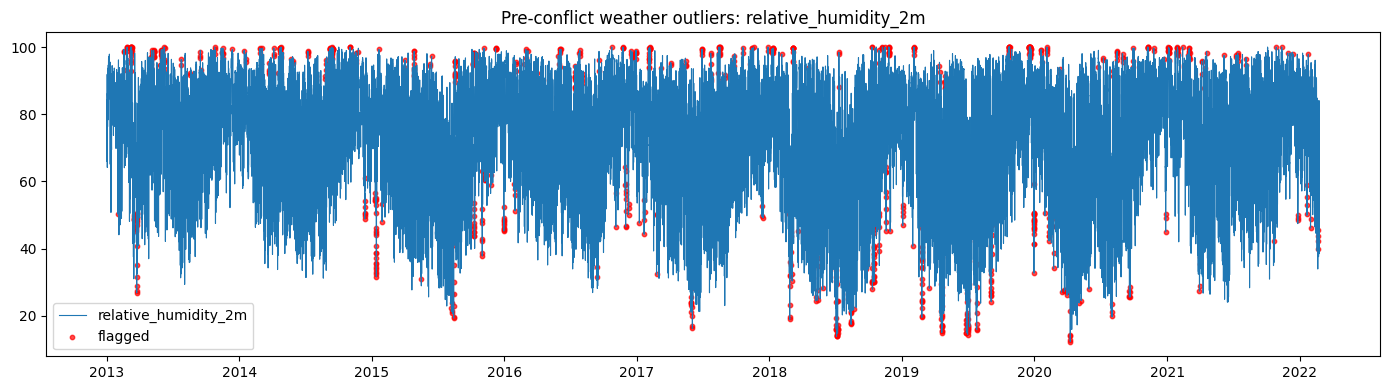

pressure_msl (pre-conflict)


,Column,Rows,Flagged,Flagged_%
2,pressure_msl,80175,1119,1.40


,timestamp,pressure_msl,period
61813,2020-01-20 13:00:00,1047.80,pre_conflict
61814,2020-01-20 14:00:00,1047.80,pre_conflict
61820,2020-01-20 20:00:00,1047.60,pre_conflict
61821,2020-01-20 21:00:00,1047.50,pre_conflict
61811,2020-01-20 11:00:00,1047.40,pre_conflict
61815,2020-01-20 15:00:00,1047.40,pre_conflict
61819,2020-01-20 19:00:00,1047.40,pre_conflict
61812,2020-01-20 12:00:00,1047.30,pre_conflict


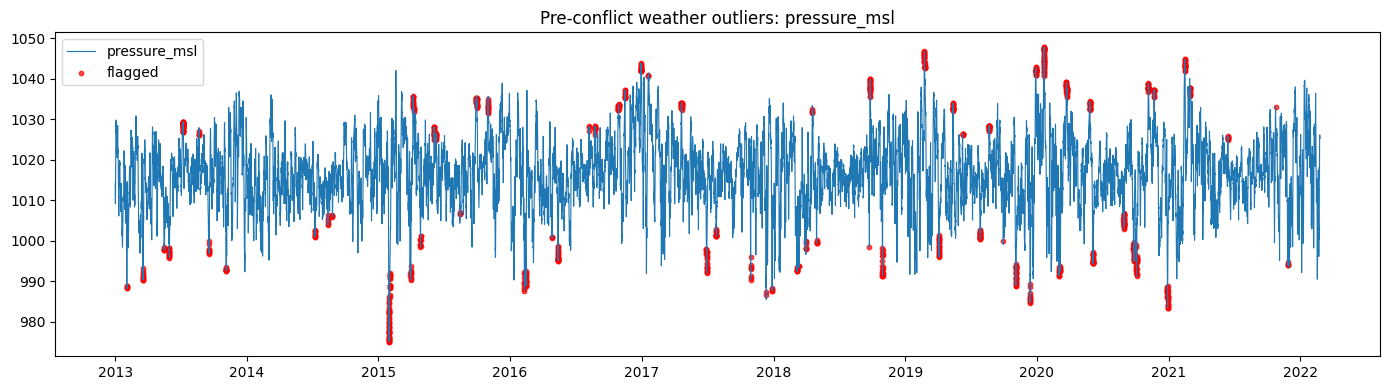

surface_pressure (pre-conflict)


,Column,Rows,Flagged,Flagged_%
3,surface_pressure,80175,1152,1.44


,timestamp,surface_pressure,period
61814,2020-01-20 14:00:00,1013.74,pre_conflict
61813,2020-01-20 13:00:00,1013.69,pre_conflict
61815,2020-01-20 15:00:00,1013.35,pre_conflict
61811,2020-01-20 11:00:00,1013.14,pre_conflict
61816,2020-01-20 16:00:00,1013.11,pre_conflict
61812,2020-01-20 12:00:00,1013.05,pre_conflict
61820,2020-01-20 20:00:00,1012.81,pre_conflict
61817,2020-01-20 17:00:00,1012.77,pre_conflict


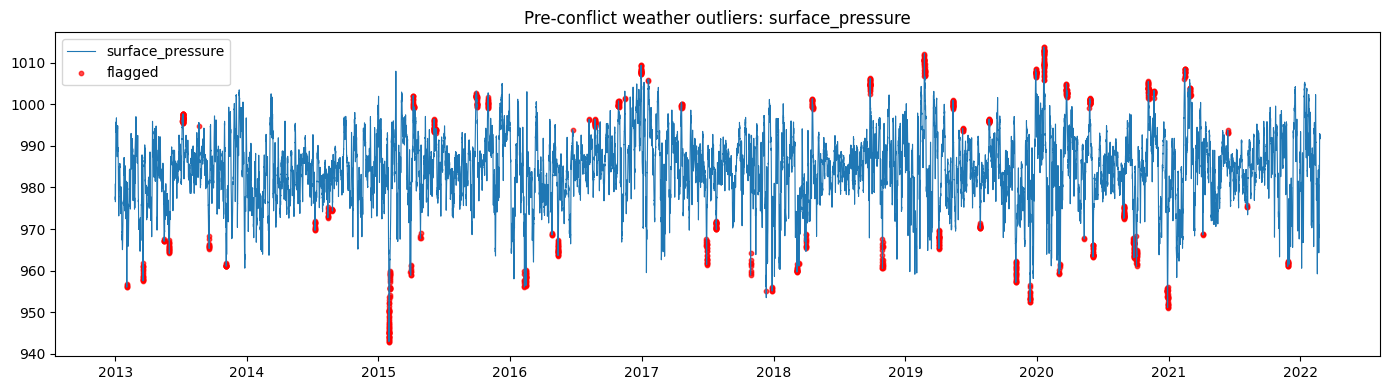

dew_point_2m (pre-conflict)


,Column,Rows,Flagged,Flagged_%
4,dew_point_2m,80175,1134,1.41


,timestamp,dew_point_2m,period
4052,2013-06-18 20:00:00,24.23,pre_conflict
45160,2018-02-25 16:00:00,-23.05,pre_conflict
4051,2013-06-18 19:00:00,22.78,pre_conflict
45158,2018-02-25 14:00:00,-22.55,pre_conflict
71214,2021-02-15 06:00:00,-22.15,pre_conflict
4067,2013-06-19 11:00:00,22.13,pre_conflict
4053,2013-06-18 21:00:00,22.13,pre_conflict
71212,2021-02-15 04:00:00,-22.10,pre_conflict


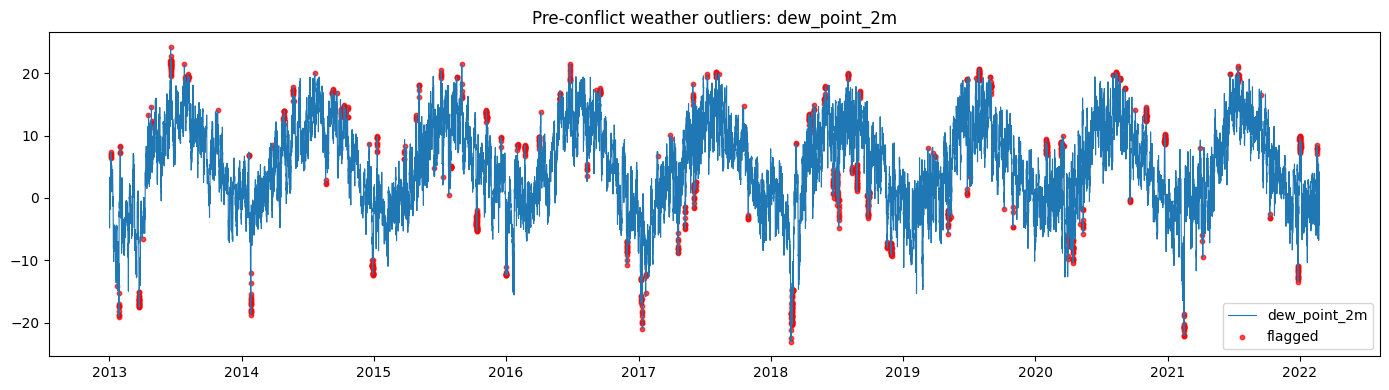

cloud_cover (pre-conflict)


,Column,Rows,Flagged,Flagged_%
5,cloud_cover,80175,2,0.00


,timestamp,cloud_cover,period
24854,2015-11-02 14:00:00,0.00,pre_conflict
77558,2021-11-06 14:00:00,0.00,pre_conflict


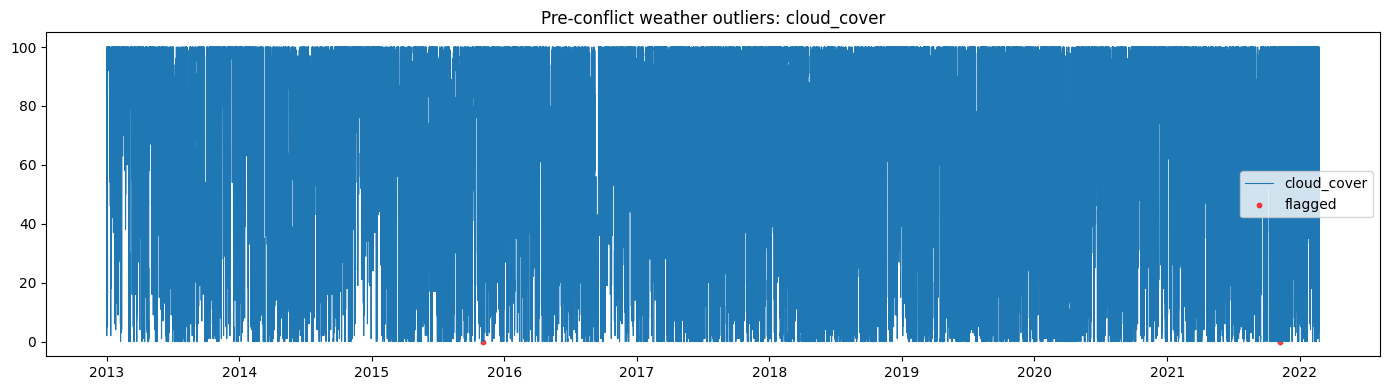

wind_speed_10m (pre-conflict)


,Column,Rows,Flagged,Flagged_%
6,wind_speed_10m,80175,1108,1.38


,timestamp,wind_speed_10m,period
77173,2021-10-21 13:00:00,53.33,pre_conflict
42299,2017-10-29 11:00:00,52.83,pre_conflict
80023,2022-02-17 07:00:00,52.80,pre_conflict
62310,2020-02-10 06:00:00,52.78,pre_conflict
42300,2017-10-29 12:00:00,51.92,pre_conflict
80027,2022-02-17 11:00:00,50.42,pre_conflict
62311,2020-02-10 07:00:00,50.01,pre_conflict
80022,2022-02-17 06:00:00,49.47,pre_conflict


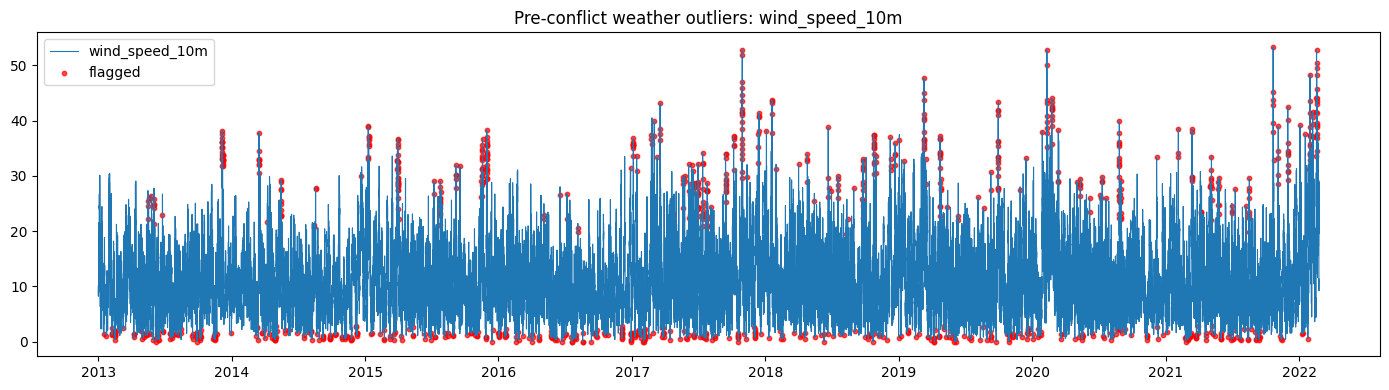

wind_direction_10m (pre-conflict)


,Column,Rows,Flagged,Flagged_%
7,wind_direction_10m,80175,972,1.21


,timestamp,wind_direction_10m,period
55790,2019-05-14 14:00:00,360.00,pre_conflict
18049,2015-01-23 01:00:00,360.00,pre_conflict
68286,2020-10-16 06:00:00,360.00,pre_conflict
5153,2013-08-03 17:00:00,360.00,pre_conflict
46962,2018-05-11 18:00:00,360.00,pre_conflict
5273,2013-08-08 17:00:00,360.00,pre_conflict
68279,2020-10-15 23:00:00,360.00,pre_conflict
33892,2016-11-13 04:00:00,360.00,pre_conflict


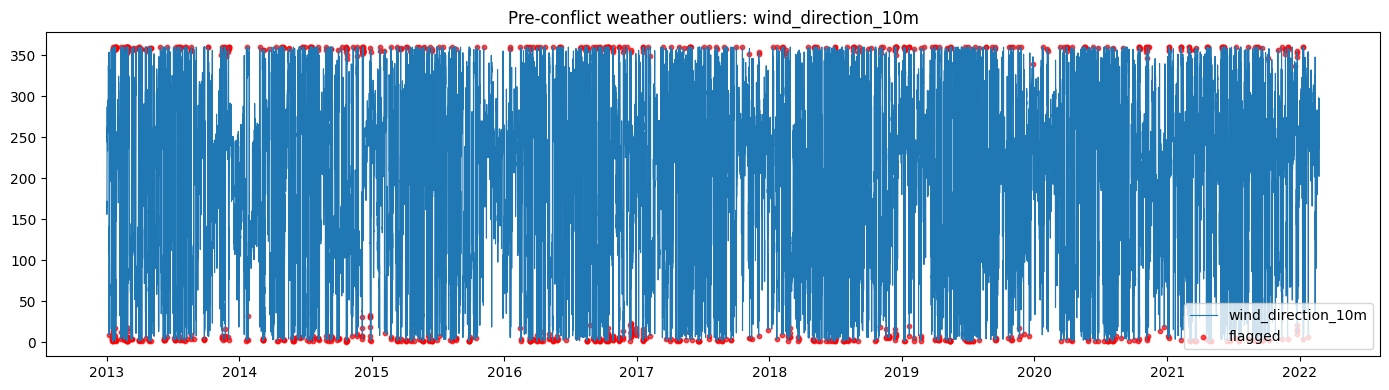

apparent_temperature (pre-conflict)


,Column,Rows,Flagged,Flagged_%
8,apparent_temperature,80175,1152,1.44


,timestamp,apparent_temperature,period
56823,2019-06-26 15:00:00,39.63,pre_conflict
56821,2019-06-26 13:00:00,38.93,pre_conflict
56822,2019-06-26 14:00:00,38.73,pre_conflict
56824,2019-06-26 16:00:00,38.67,pre_conflict
56820,2019-06-26 12:00:00,37.74,pre_conflict
40167,2017-08-01 15:00:00,37.64,pre_conflict
40168,2017-08-01 16:00:00,37.24,pre_conflict
5007,2013-07-28 15:00:00,37.09,pre_conflict


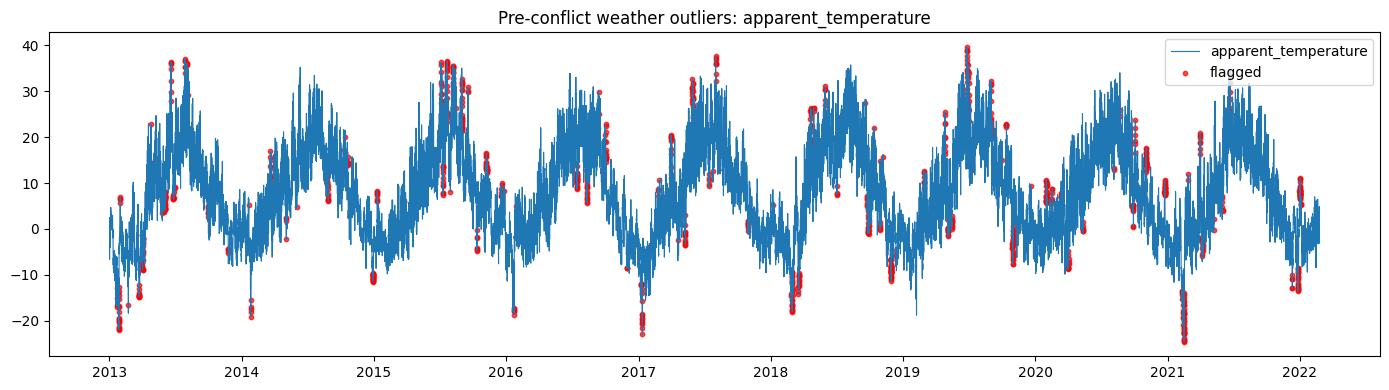

wind_gusts_10m (pre-conflict)


,Column,Rows,Flagged,Flagged_%
9,wind_gusts_10m,80175,1045,1.30


,timestamp,wind_gusts_10m,period
42301,2017-10-29 13:00:00,105.48,pre_conflict
42296,2017-10-29 08:00:00,105.12,pre_conflict
62317,2020-02-10 13:00:00,104.04,pre_conflict
77174,2021-10-21 14:00:00,103.32,pre_conflict
80022,2022-02-17 06:00:00,100.80,pre_conflict
42297,2017-10-29 09:00:00,100.44,pre_conflict
42300,2017-10-29 12:00:00,99.72,pre_conflict
42295,2017-10-29 07:00:00,99.00,pre_conflict


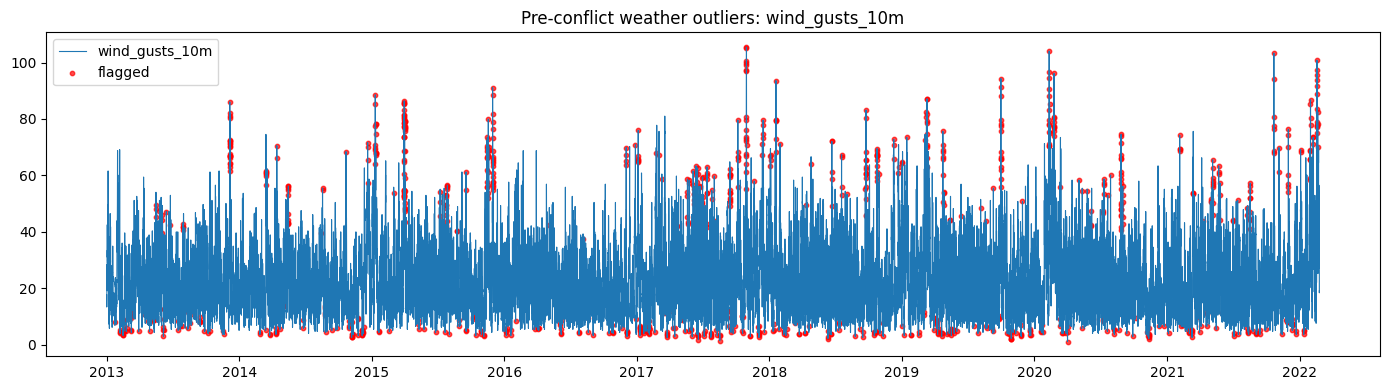

precipitation (pre-conflict)


,Column,Rows,Flagged,Flagged_%
10,precipitation,80175,510,0.64


,timestamp,precipitation,period
66505,2020-08-03 01:00:00,14.10,pre_conflict
66506,2020-08-03 02:00:00,12.00,pre_conflict
65319,2020-06-14 15:00:00,10.30,pre_conflict
39351,2017-06-28 15:00:00,10.00,pre_conflict
65414,2020-06-18 14:00:00,9.00,pre_conflict
66786,2020-08-14 18:00:00,8.70,pre_conflict
75384,2021-08-08 00:00:00,7.60,pre_conflict
74780,2021-07-13 20:00:00,7.40,pre_conflict


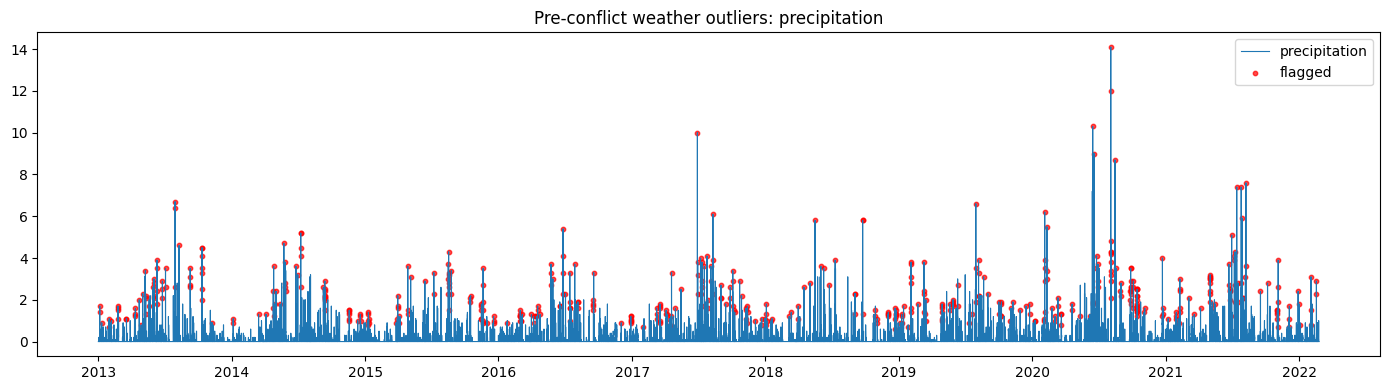

snowfall (pre-conflict)


,Column,Rows,Flagged,Flagged_%
11,snowfall,80175,226,0.28


,timestamp,snowfall,period
62166,2020-02-04 06:00:00,2.59,pre_conflict
53385,2019-02-03 09:00:00,2.59,pre_conflict
53386,2019-02-03 10:00:00,2.59,pre_conflict
53387,2019-02-03 11:00:00,2.17,pre_conflict
71043,2021-02-08 03:00:00,2.10,pre_conflict
53384,2019-02-03 08:00:00,1.96,pre_conflict
71042,2021-02-08 02:00:00,1.75,pre_conflict
71044,2021-02-08 04:00:00,1.68,pre_conflict


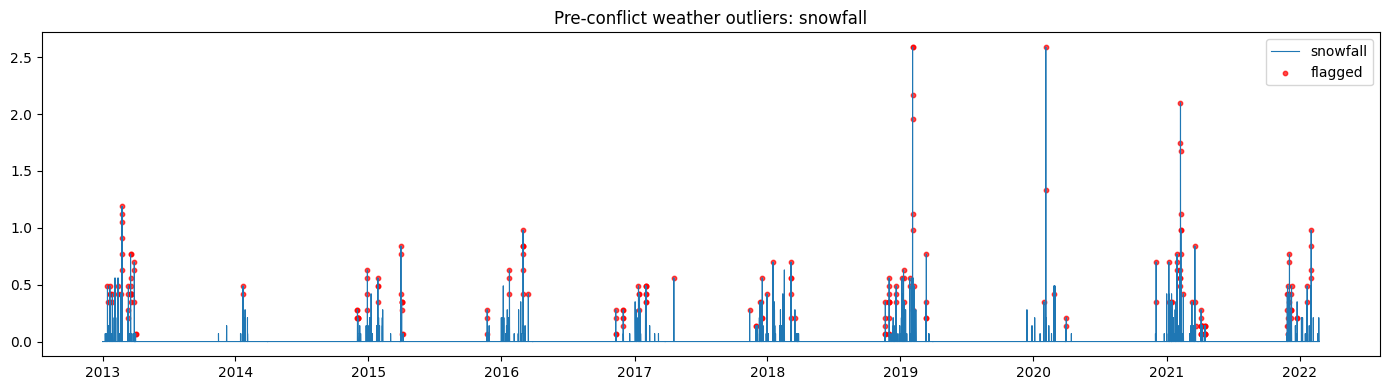

snow_depth (pre-conflict)


,Column,Rows,Flagged,Flagged_%
12,snow_depth,80175,158,0.20


,timestamp,snow_depth,period
1307,2013-02-24 11:00:00,0.19,pre_conflict
1304,2013-02-24 08:00:00,0.19,pre_conflict
1305,2013-02-24 09:00:00,0.19,pre_conflict
1306,2013-02-24 10:00:00,0.19,pre_conflict
1308,2013-02-24 12:00:00,0.19,pre_conflict
1309,2013-02-24 13:00:00,0.18,pre_conflict
1303,2013-02-24 07:00:00,0.18,pre_conflict
1311,2013-02-24 15:00:00,0.18,pre_conflict


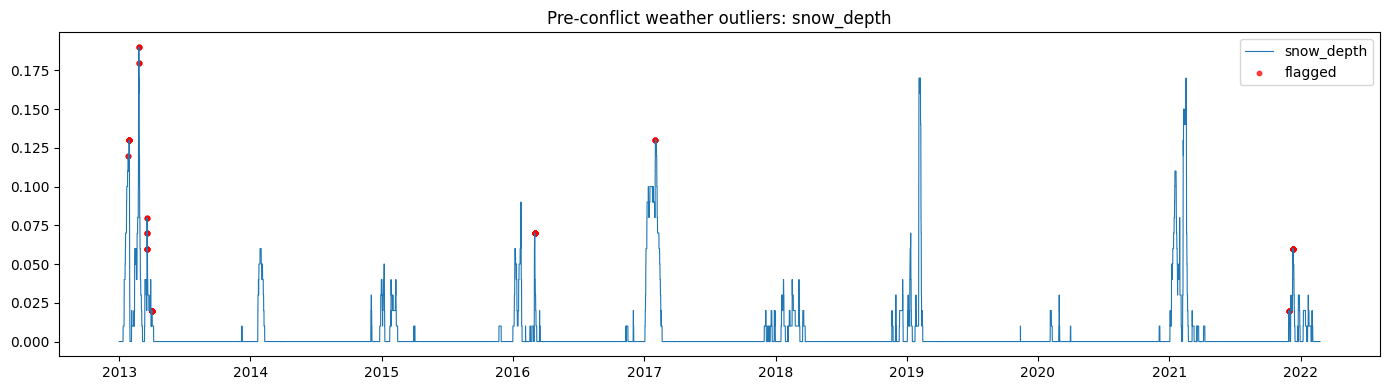

In [23]:
# Before conflict - Weather outlier diagnostics (contextual by month/hour)
pre_df = df_eda[df_eda["period"] == "pre_conflict"].copy()

for col in WEATHER_VARIABLES:
    if col not in pre_df.columns:
        continue
    s = pd.to_numeric(pre_df[col], errors="coerce")
    lo = pre_df.groupby(["month", "hour"])[col].transform(
        lambda x: pd.to_numeric(x, errors="coerce").quantile(0.005)
    )
    hi = pre_df.groupby(["month", "hour"])[col].transform(
        lambda x: pd.to_numeric(x, errors="coerce").quantile(0.995)
    )
    pre_df[f"{col}_flag_weather"] = (s < lo) | (s > hi)

summary_pre_weather = summary_from_flags(pre_df, WEATHER_VARIABLES, "flag_weather")

for col in WEATHER_VARIABLES:
    flag_col = f"{col}_flag_weather"
    if col not in pre_df.columns or flag_col not in pre_df.columns:
        continue

    print(f"{col} (pre-conflict)")
    display(summary_pre_weather[summary_pre_weather["Column"] == col])
    display(top_flagged_rows(pre_df, col, flag_col, n=8))

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(pre_df[timestamp_col], pre_df[col], linewidth=0.8, label=col)
    flagged = pre_df[pre_df[flag_col]]
    ax.scatter(
        flagged[timestamp_col],
        flagged[col],
        s=10,
        color="red",
        alpha=0.7,
        label="flagged",
    )
    ax.set_title(f"Pre-conflict weather outliers: {col}")
    ax.legend()
    plt.tight_layout()
    plt.show()

All weather variables are withing range so that's good. There are no extreme outliers.

#### Price

traded_volume_mwh (pre-conflict)
Daily-level summary:


,Column,Rows,Flagged,Flagged_%
0,traded_volume_mwh,3341,15,0.45


Hourly-mapped summary:


,Column,Rows,Flagged,Flagged_%
0,traded_volume_mwh,80184,360,0.45


,date,traded_volume_mwh
72432,2021-04-07,82021.80
35760,2017-01-30,59400.60
35112,2017-01-03,56995.80
20736,2015-05-15,56676.00
76704,2021-10-02,55912.40
64344,2020-05-05,51540.80
59808,2019-10-29,51039.00
59304,2019-10-08,50182.00
54816,2019-04-04,47873.00
45264,2018-03-02,46438.60


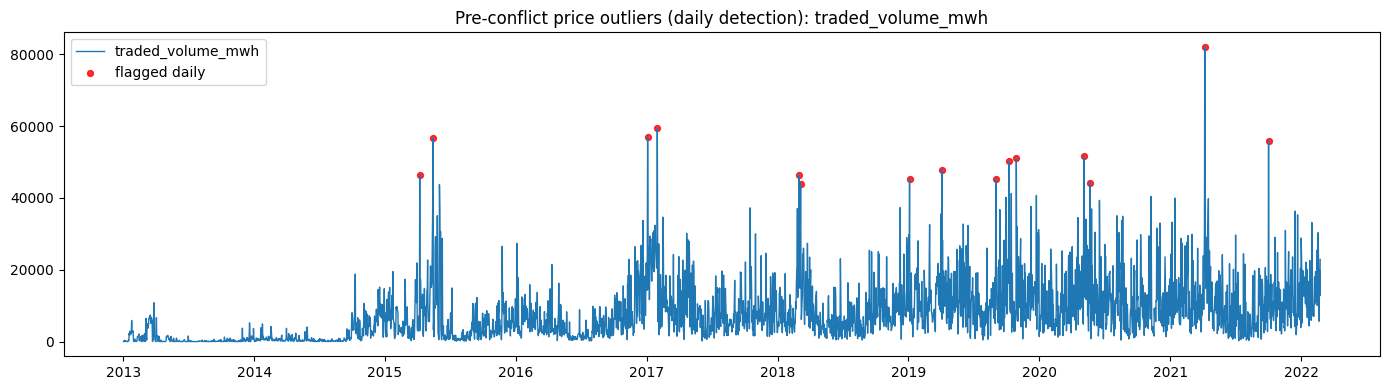

weighted_avg_price_eur_mwh (pre-conflict)
Daily-level summary:


,Column,Rows,Flagged,Flagged_%
1,weighted_avg_price_eur_mwh,3282,163,4.97


Hourly-mapped summary:


,Column,Rows,Flagged,Flagged_%
1,weighted_avg_price_eur_mwh,78768,3912,4.97


,date,weighted_avg_price_eur_mwh
78648,2021-12-22,177.83
78624,2021-12-21,168.68
78672,2021-12-23,158.70
78600,2021-12-20,146.64
78576,2021-12-19,145.82
...,...,...
76392,2021-09-19,63.51
76272,2021-09-14,61.39
76560,2021-09-26,60.00
76248,2021-09-13,59.89


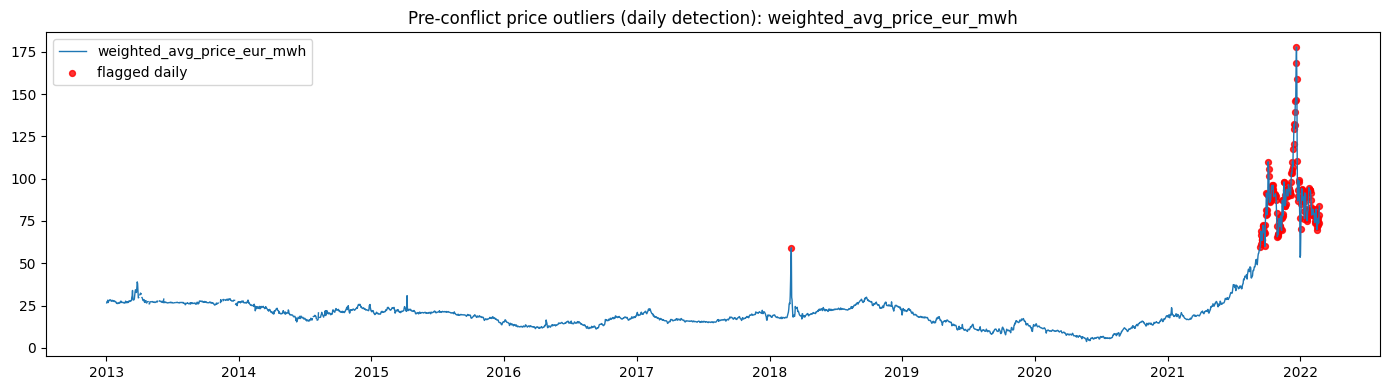

min_price_eur_mwh (pre-conflict)
Daily-level summary:


,Column,Rows,Flagged,Flagged_%
2,min_price_eur_mwh,3282,158,4.81


Hourly-mapped summary:


,Column,Rows,Flagged,Flagged_%
2,min_price_eur_mwh,78768,3792,4.81


,date,min_price_eur_mwh
78648,2021-12-22,170.00
78624,2021-12-21,145.51
78600,2021-12-20,145.50
78576,2021-12-19,139.50
78552,2021-12-18,136.79
...,...,...
77376,2021-10-30,61.30
79992,2022-02-16,61.01
76272,2021-09-14,60.80
76320,2021-09-16,59.00


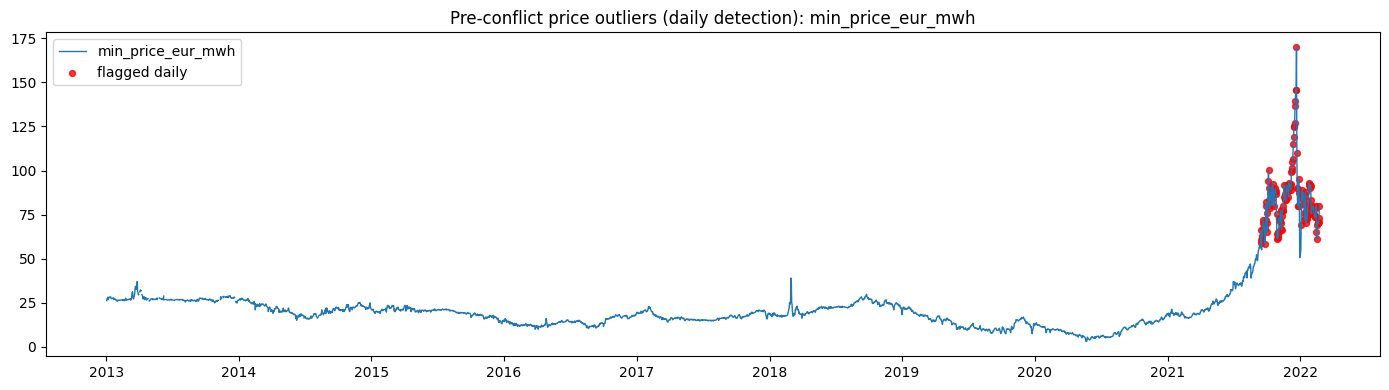

max_price_eur_mwh (pre-conflict)
Daily-level summary:


,Column,Rows,Flagged,Flagged_%
3,max_price_eur_mwh,3282,169,5.15


Hourly-mapped summary:


,Column,Rows,Flagged,Flagged_%
3,max_price_eur_mwh,78768,4056,5.15


,date,max_price_eur_mwh
51888,2018-12-03,1000.00
78624,2021-12-21,200.00
78648,2021-12-22,184.98
78672,2021-12-23,176.00
78576,2021-12-19,165.00
...,...,...
76368,2021-09-18,66.01
76392,2021-09-19,65.00
78912,2022-01-02,62.00
76248,2021-09-13,62.00


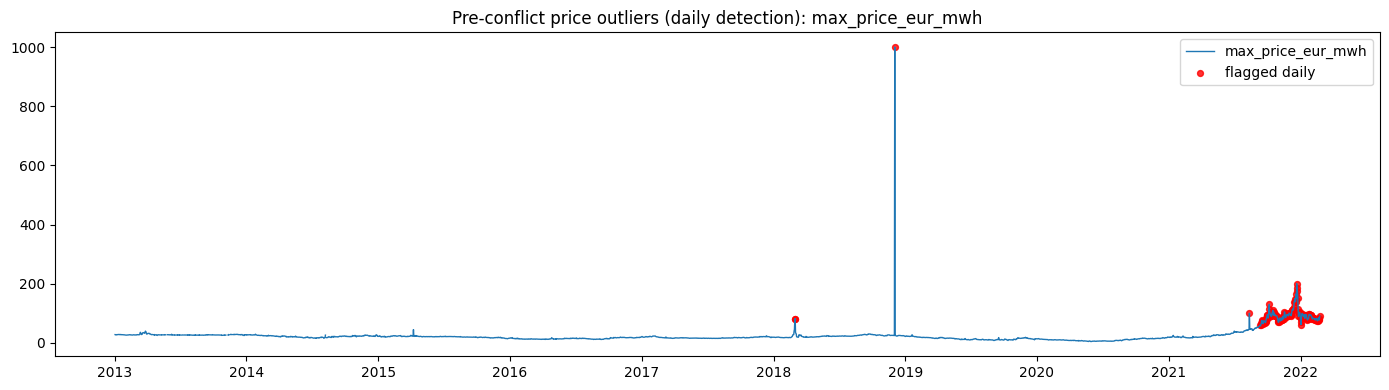

In [24]:
# Before conflict - Price outlier diagnostics (daily first, then mapped back to hourly)
pre_df = df_eda[df_eda["period"] == "pre_conflict"].copy()
price_daily_frames = []

for col in PRICE_VARIABLES:
    if col not in pre_df.columns:
        continue
    daily = pre_df.groupby("date", as_index=False)[col].median()
    z = mad_zscore(daily[col])
    daily[f"{col}_flag_price_daily"] = z.abs() > 6
    price_daily_frames.append(daily[["date", f"{col}_flag_price_daily", col]])

if price_daily_frames:
    merged_daily = price_daily_frames[0]
    for d in price_daily_frames[1:]:
        merged_daily = merged_daily.merge(d, on="date", how="outer")

    for col in PRICE_VARIABLES:
        flag_col = f"{col}_flag_price_daily"
        if flag_col in merged_daily.columns:
            pre_df = pre_df.merge(
                merged_daily[["date", flag_col]], on="date", how="left"
            )
            pre_df[flag_col] = pre_df[flag_col].fillna(False)

summary_pre_price_daily = summary_from_flags(
    pre_df.drop_duplicates(subset=["date"]), PRICE_VARIABLES, "flag_price_daily"
)
summary_pre_price_hourly = summary_from_flags(
    pre_df, PRICE_VARIABLES, "flag_price_daily"
)

for col in PRICE_VARIABLES:
    flag_col = f"{col}_flag_price_daily"
    if col not in pre_df.columns or flag_col not in pre_df.columns:
        continue

    print(f"{col} (pre-conflict)")
    print("Daily-level summary:")
    display(summary_pre_price_daily[summary_pre_price_daily["Column"] == col])
    print("Hourly-mapped summary:")
    display(summary_pre_price_hourly[summary_pre_price_hourly["Column"] == col])

    top_daily = (
        pre_df.loc[pre_df[flag_col], ["date", col]]
        .drop_duplicates(subset=["date"])
        .sort_values(col, key=lambda s: s.abs(), ascending=False)
    )
    display(top_daily)

    price_plot = pre_df.drop_duplicates(subset=["date"])[["date", col, flag_col]].copy()
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(price_plot["date"], price_plot[col], linewidth=1, label=col)
    flagged = price_plot[price_plot[flag_col]]
    ax.scatter(
        flagged["date"],
        flagged[col],
        s=18,
        color="red",
        alpha=0.8,
        label="flagged daily",
    )
    ax.set_title(f"Pre-conflict price outliers (daily detection): {col}")
    ax.legend()
    plt.tight_layout()
    plt.show()

In **max_price_eur_mwh** we have one extreme outlier so we have to deal with it.

That one value after *2018* is consistent across all price related variables, so it is not an error in one variable but in the source data. 

Around year we have many values flagged as outliers, but this is the observed and desired behavior because of _Russo-Ukrainian war_.

### After conflict

#### Consumption

consumption_gasnet (post-conflict)
Value range: min=0.00, max=696,610.00 | P01/P50/P99=113,159.34 / 237,459.50 / 546,757.13


,Column,Rows,Flagged,Flagged_%
0,consumption_gasnet,33768,273,0.81


,timestamp,consumption_gasnet,period
106328,2025-02-17 08:00:00,696610.00,post_conflict
106376,2025-02-19 08:00:00,668570.00,post_conflict
106377,2025-02-19 09:00:00,660586.00,post_conflict
106329,2025-02-17 09:00:00,658724.00,post_conflict
106375,2025-02-19 07:00:00,657881.00,post_conflict
106400,2025-02-20 08:00:00,657321.00,post_conflict
106352,2025-02-18 08:00:00,653408.00,post_conflict
96609,2024-01-09 09:00:00,645223.00,post_conflict
106399,2025-02-20 07:00:00,644091.00,post_conflict
96633,2024-01-10 09:00:00,642662.00,post_conflict


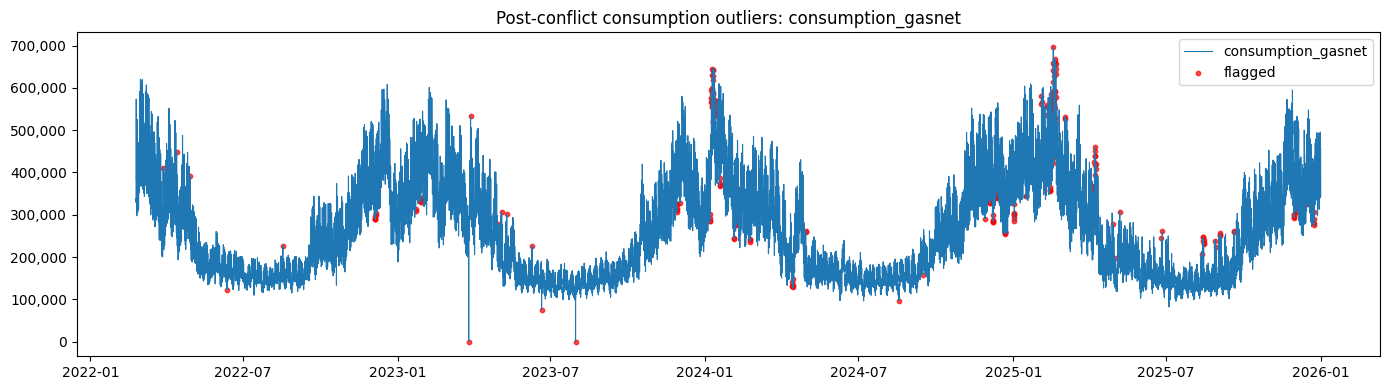

consumption_jmpnet (post-conflict)
Value range: min=0.00, max=517,464.00 | P01/P50/P99=33,255.34 / 122,551.00 / 392,992.63


,Column,Rows,Flagged,Flagged_%
1,consumption_jmpnet,33768,732,2.17


,timestamp,consumption_jmpnet,period
96632,2024-01-10 08:00:00,517464.00,post_conflict
96633,2024-01-10 09:00:00,513012.00,post_conflict
96631,2024-01-10 07:00:00,512857.00,post_conflict
96656,2024-01-11 08:00:00,509115.00,post_conflict
96657,2024-01-11 09:00:00,505560.00,post_conflict
96609,2024-01-09 09:00:00,503313.00,post_conflict
96584,2024-01-08 08:00:00,502426.00,post_conflict
106376,2025-02-19 08:00:00,500677.00,post_conflict
96655,2024-01-11 07:00:00,496574.00,post_conflict
96608,2024-01-09 08:00:00,493492.00,post_conflict


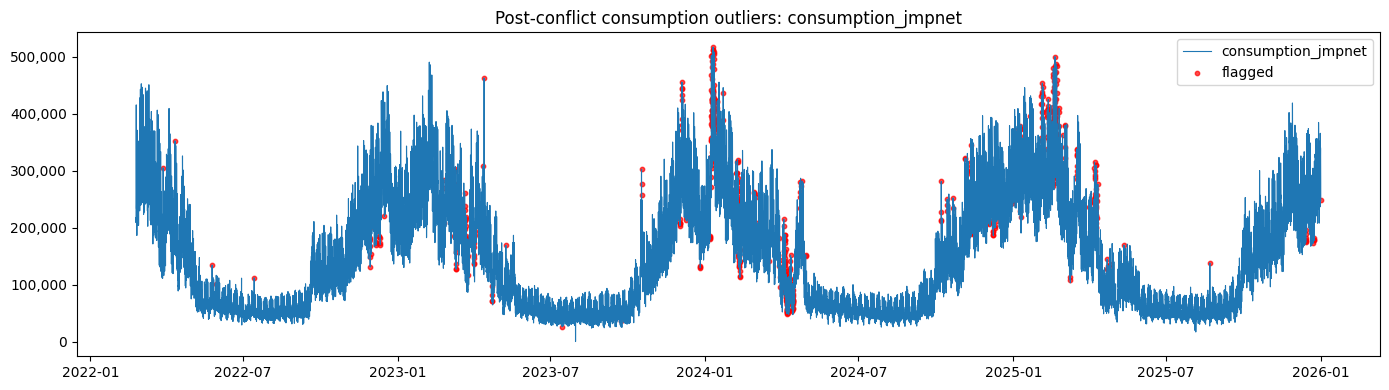

consumption_smpnet (post-conflict)
Value range: min=-18,321.00, max=412,861.00 | P01/P50/P99=49,420.67 / 116,774.50 / 312,301.12


,Column,Rows,Flagged,Flagged_%
2,consumption_smpnet,33768,374,1.11


,timestamp,consumption_smpnet,period
106376,2025-02-19 08:00:00,412861.00,post_conflict
96633,2024-01-10 09:00:00,405657.00,post_conflict
96634,2024-01-10 10:00:00,403514.00,post_conflict
96608,2024-01-09 08:00:00,397142.00,post_conflict
96632,2024-01-10 08:00:00,396487.00,post_conflict
106328,2025-02-17 08:00:00,394256.00,post_conflict
106375,2025-02-19 07:00:00,391296.00,post_conflict
96610,2024-01-09 10:00:00,390726.00,post_conflict
96609,2024-01-09 09:00:00,390336.00,post_conflict
81342,2022-04-13 06:00:00,389750.00,post_conflict


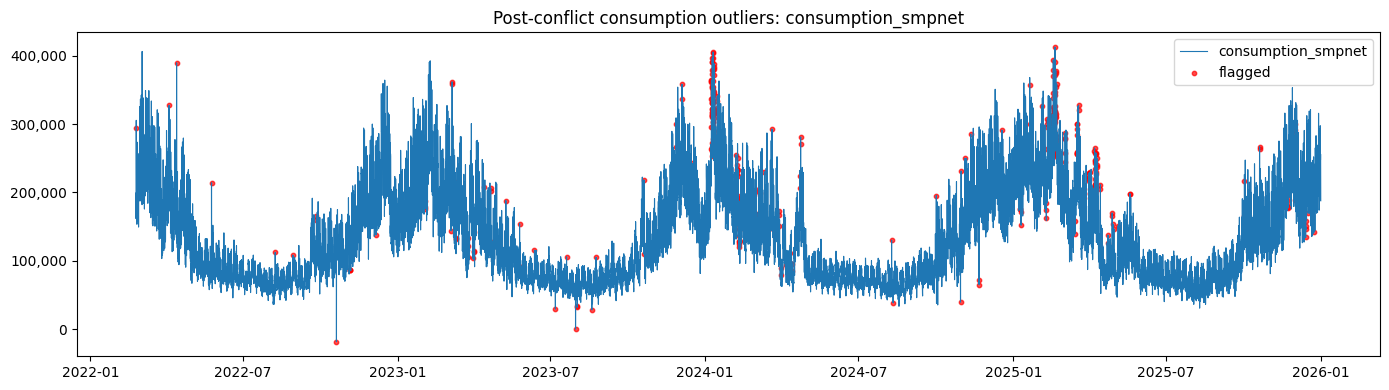

consumption_vcpnet (post-conflict)
Value range: min=0.00, max=259,441.00 | P01/P50/P99=20,613.74 / 64,221.00 / 193,149.28


,Column,Rows,Flagged,Flagged_%
3,consumption_vcpnet,33768,340,1.01


,timestamp,consumption_vcpnet,period
106328,2025-02-17 08:00:00,259441.00,post_conflict
106376,2025-02-19 08:00:00,254823.00,post_conflict
96632,2024-01-10 08:00:00,248993.00,post_conflict
106352,2025-02-18 08:00:00,248528.00,post_conflict
96609,2024-01-09 09:00:00,246749.00,post_conflict
106375,2025-02-19 07:00:00,246165.00,post_conflict
96633,2024-01-10 09:00:00,245217.00,post_conflict
96608,2024-01-09 08:00:00,244641.00,post_conflict
106400,2025-02-20 08:00:00,244600.00,post_conflict
96657,2024-01-11 09:00:00,243889.00,post_conflict


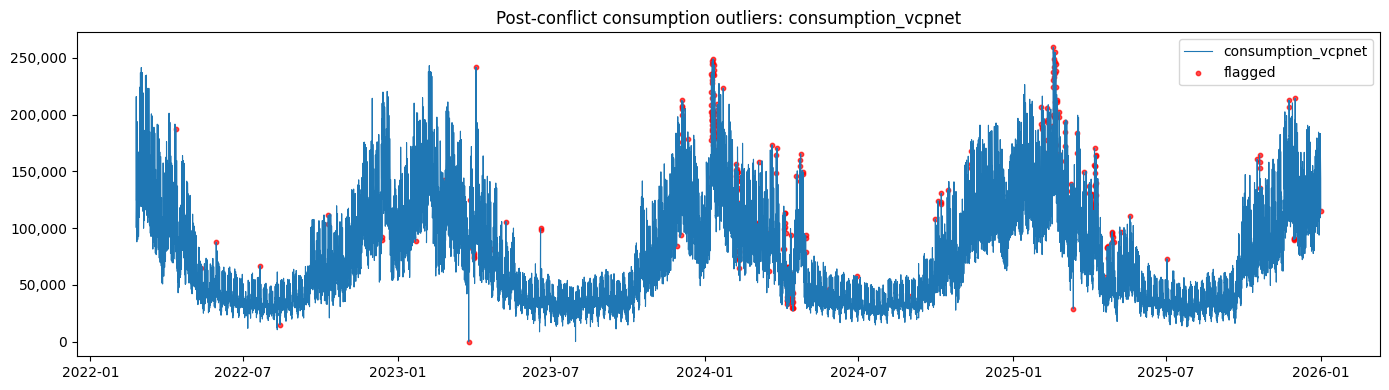

In [25]:
# After conflict - Consumption outlier diagnostics
post_df = df_eda[df_eda["period"] == "post_conflict"].copy()
consumption_cols = [
    col
    for col in CONSUMPTION_VARIABLES
    if col != "consumption_total" and col in post_df.columns
]

for col in consumption_cols:
    post_df[f"{col}_flag_roll24"] = rolling_robust_flag(
        post_df[col], window=24, threshold=OUTLIER_CFG["rolling_threshold"]
    )
    post_df[f"{col}_flag_roll168"] = rolling_robust_flag(
        post_df[col], window=168, threshold=OUTLIER_CFG["rolling_threshold"]
    )

    lag_24h_365d = pd.to_numeric(post_df[col], errors="coerce").shift(24 * 365)
    yoy_delta = pd.to_numeric(post_df[col], errors="coerce") - lag_24h_365d
    yoy_score = mad_zscore(yoy_delta)
    post_df[f"{col}_flag_yoy"] = yoy_score.abs() > OUTLIER_CFG["yoy_mad_threshold"]

    post_df[f"{col}_flag_cons"] = (
        post_df[f"{col}_flag_roll24"].fillna(False)
        | post_df[f"{col}_flag_roll168"].fillna(False)
        | post_df[f"{col}_flag_yoy"].fillna(False)
    )

summary_post_cons = summary_from_flags(post_df, consumption_cols, "flag_cons")

for col in consumption_cols:
    flag_col = f"{col}_flag_cons"
    series = pd.to_numeric(post_df[col], errors="coerce")
    q01 = series.quantile(0.01)
    q50 = series.quantile(0.50)
    q99 = series.quantile(0.99)

    print(f"{col} (post-conflict)")
    print(
        f"Value range: min={series.min():,.2f}, max={series.max():,.2f} | "
        f"P01/P50/P99={q01:,.2f} / {q50:,.2f} / {q99:,.2f}"
    )
    display(summary_post_cons[summary_post_cons["Column"] == col])
    display(top_flagged_rows(post_df, col, flag_col, n=10))

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(post_df[timestamp_col], post_df[col], linewidth=0.8, label=col)
    flagged = post_df[post_df[flag_col]]
    ax.scatter(
        flagged[timestamp_col],
        flagged[col],
        s=10,
        color="red",
        alpha=0.7,
        label="flagged",
    )
    ax.ticklabel_format(style="plain", axis="y", useOffset=False)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:,.0f}"))
    ax.set_title(f"Post-conflict consumption outliers: {col}")
    ax.legend()
    plt.tight_layout()
    plt.show()

Zero values are problematic, otherwise we don't have any extreme outliers and data looks good.

#### Weather variables

temperature_2m (post-conflict)


,Column,Rows,Flagged,Flagged_%
0,temperature_2m,33764,564,1.67


,timestamp,temperature_2m,period
82960,2022-06-19 16:00:00,37.00,post_conflict
82961,2022-06-19 17:00:00,36.50,post_conflict
110631,2025-08-15 15:00:00,36.25,post_conflict
110632,2025-08-15 16:00:00,36.25,post_conflict
109576,2025-07-02 16:00:00,36.25,post_conflict
110630,2025-08-15 14:00:00,36.20,post_conflict
82959,2022-06-19 15:00:00,36.15,post_conflict
109575,2025-07-02 15:00:00,36.05,post_conflict


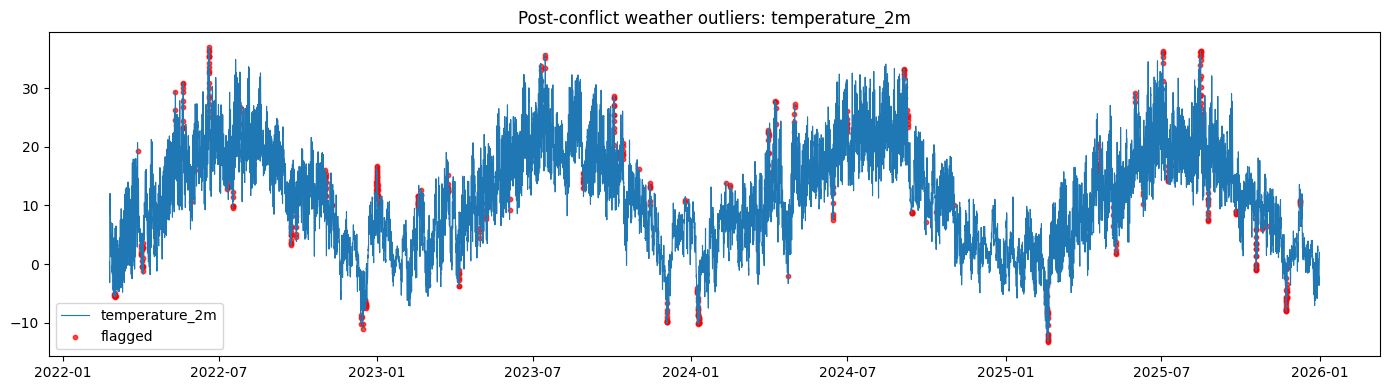

relative_humidity_2m (post-conflict)


,Column,Rows,Flagged,Flagged_%
1,relative_humidity_2m,33764,572,1.69


,timestamp,relative_humidity_2m,period
95982,2023-12-14 06:00:00,100.00,post_conflict
99987,2024-05-29 03:00:00,100.00,post_conflict
86735,2022-11-23 23:00:00,100.00,post_conflict
94659,2023-10-20 03:00:00,100.00,post_conflict
81244,2022-04-09 04:00:00,100.00,post_conflict
103253,2024-10-12 05:00:00,100.00,post_conflict
86541,2022-11-15 21:00:00,100.00,post_conflict
97927,2024-03-04 07:00:00,100.00,post_conflict


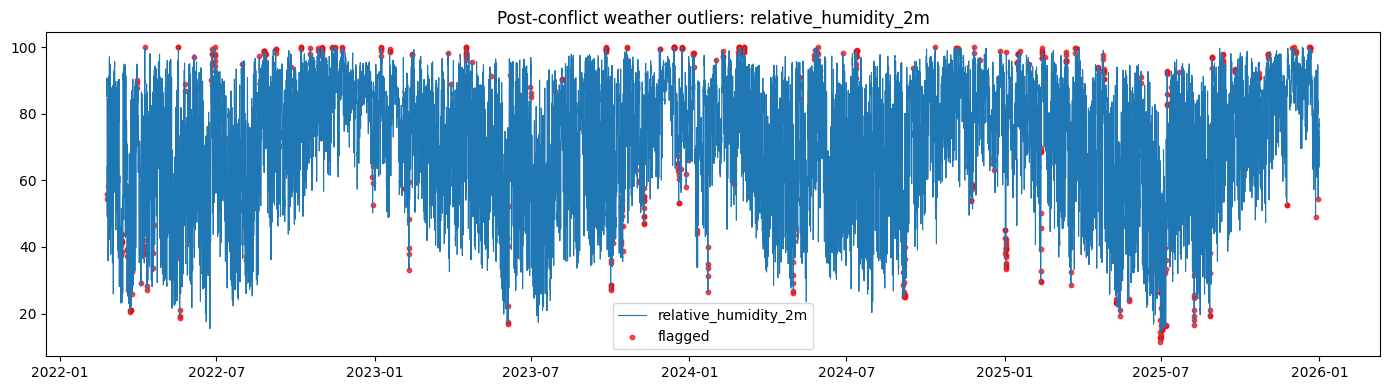

pressure_msl (post-conflict)


,Column,Rows,Flagged,Flagged_%
2,pressure_msl,33764,555,1.64


,timestamp,pressure_msl,period
88569,2023-02-08 09:00:00,1044.60,post_conflict
88570,2023-02-08 10:00:00,1044.50,post_conflict
88568,2023-02-08 08:00:00,1044.40,post_conflict
88571,2023-02-08 11:00:00,1044.20,post_conflict
105490,2025-01-13 10:00:00,1044.10,post_conflict
105491,2025-01-13 11:00:00,1044.10,post_conflict
88567,2023-02-08 07:00:00,1043.90,post_conflict
105492,2025-01-13 12:00:00,1043.90,post_conflict


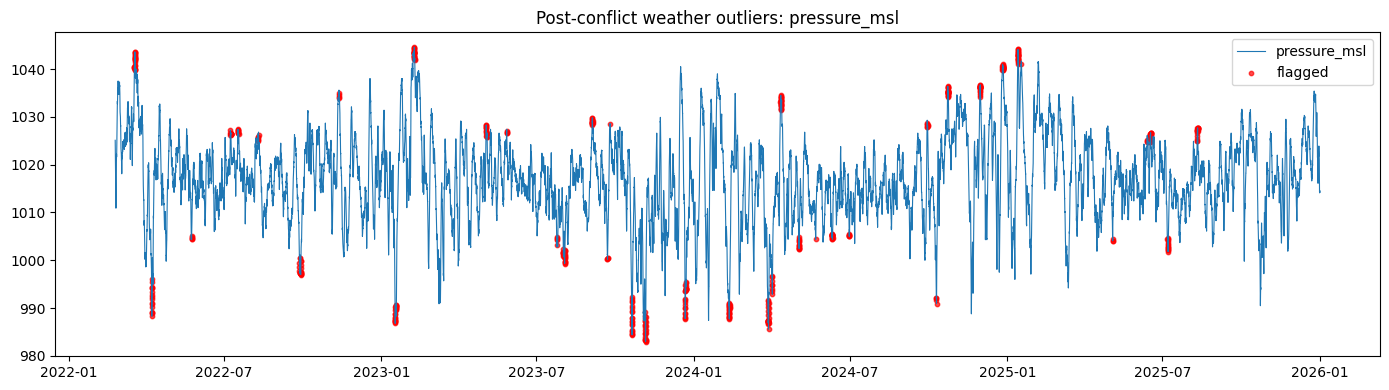

surface_pressure (post-conflict)


,Column,Rows,Flagged,Flagged_%
3,surface_pressure,33764,575,1.70


,timestamp,surface_pressure,period
88570,2023-02-08 10:00:00,1009.73,post_conflict
88571,2023-02-08 11:00:00,1009.65,post_conflict
105491,2025-01-13 11:00:00,1009.62,post_conflict
88569,2023-02-08 09:00:00,1009.56,post_conflict
105490,2025-01-13 10:00:00,1009.51,post_conflict
105492,2025-01-13 12:00:00,1009.48,post_conflict
80734,2022-03-18 22:00:00,1009.32,post_conflict
80735,2022-03-18 23:00:00,1009.30,post_conflict


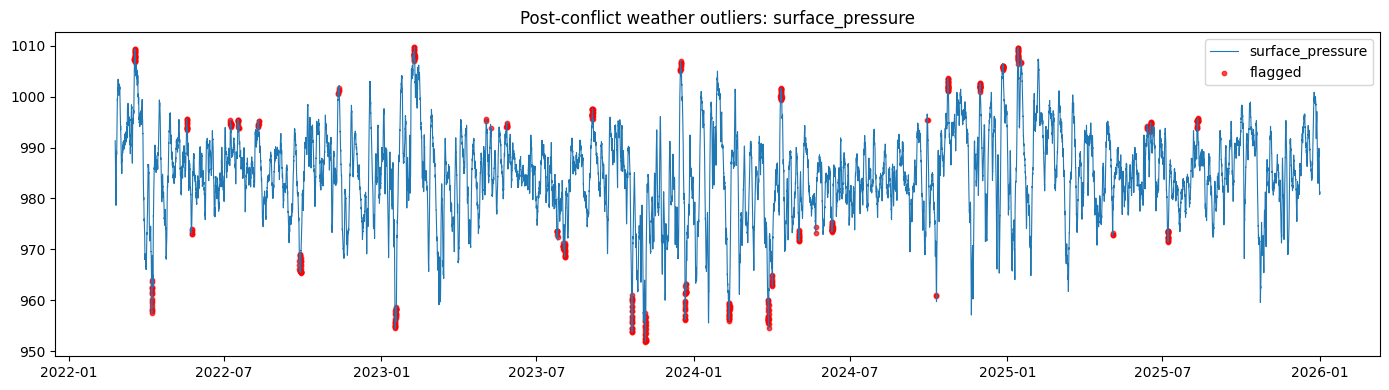

dew_point_2m (post-conflict)


,Column,Rows,Flagged,Flagged_%
4,dew_point_2m,33764,569,1.69


,timestamp,dew_point_2m,period
83156,2022-06-27 20:00:00,22.85,post_conflict
93068,2023-08-14 20:00:00,22.25,post_conflict
93067,2023-08-14 19:00:00,22.15,post_conflict
93069,2023-08-14 21:00:00,21.25,post_conflict
93061,2023-08-14 13:00:00,21.20,post_conflict
101016,2024-07-11 00:00:00,20.80,post_conflict
83155,2022-06-27 19:00:00,20.80,post_conflict
93060,2023-08-14 12:00:00,20.75,post_conflict


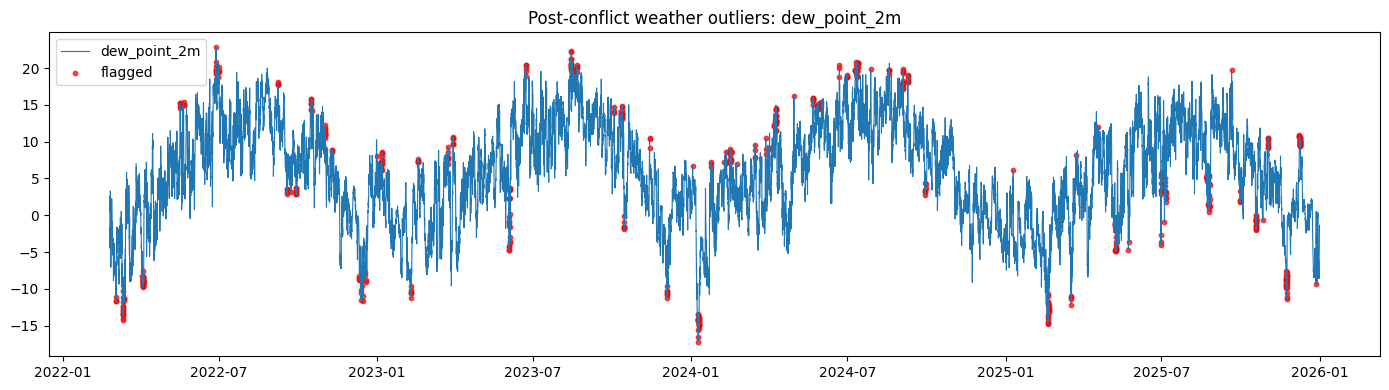

cloud_cover (post-conflict)


,Column,Rows,Flagged,Flagged_%
5,cloud_cover,33764,2,0.01


,timestamp,cloud_cover,period
85647,2022-10-09 15:00:00,0.00,post_conflict
113029,2025-11-23 13:00:00,0.00,post_conflict


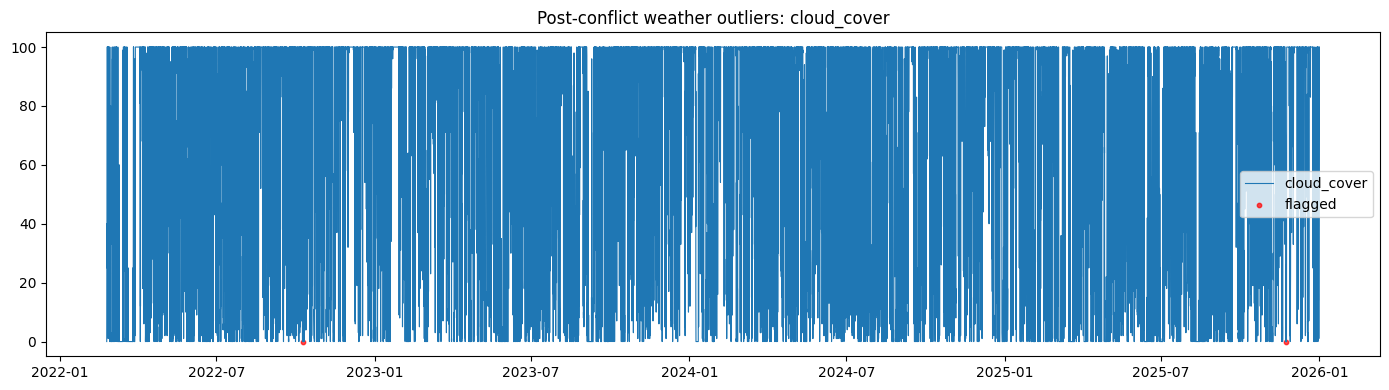

wind_speed_10m (post-conflict)


,Column,Rows,Flagged,Flagged_%
6,wind_speed_10m,33764,559,1.66


,timestamp,wind_speed_10m,period
102590,2024-09-14 14:00:00,42.83,post_conflict
96160,2023-12-21 16:00:00,41.25,post_conflict
96162,2023-12-21 18:00:00,39.73,post_conflict
96972,2024-01-24 12:00:00,38.94,post_conflict
98389,2024-03-23 13:00:00,38.92,post_conflict
96973,2024-01-24 13:00:00,38.69,post_conflict
88455,2023-02-03 15:00:00,38.56,post_conflict
96180,2023-12-22 12:00:00,38.31,post_conflict


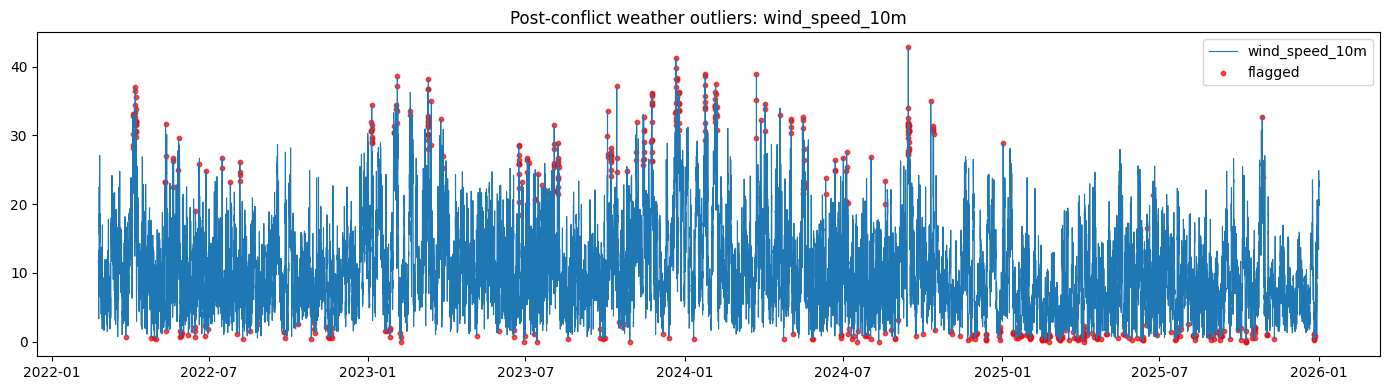

wind_direction_10m (post-conflict)


,Column,Rows,Flagged,Flagged_%
7,wind_direction_10m,33764,532,1.58


,timestamp,wind_direction_10m,period
96536,2024-01-06 08:00:00,360.00,post_conflict
89112,2023-03-03 00:00:00,360.00,post_conflict
95966,2023-12-13 14:00:00,360.00,post_conflict
95688,2023-12-02 00:00:00,360.00,post_conflict
95684,2023-12-01 20:00:00,360.00,post_conflict
95681,2023-12-01 17:00:00,360.00,post_conflict
94987,2023-11-02 19:00:00,360.00,post_conflict
93566,2023-09-04 14:00:00,360.00,post_conflict


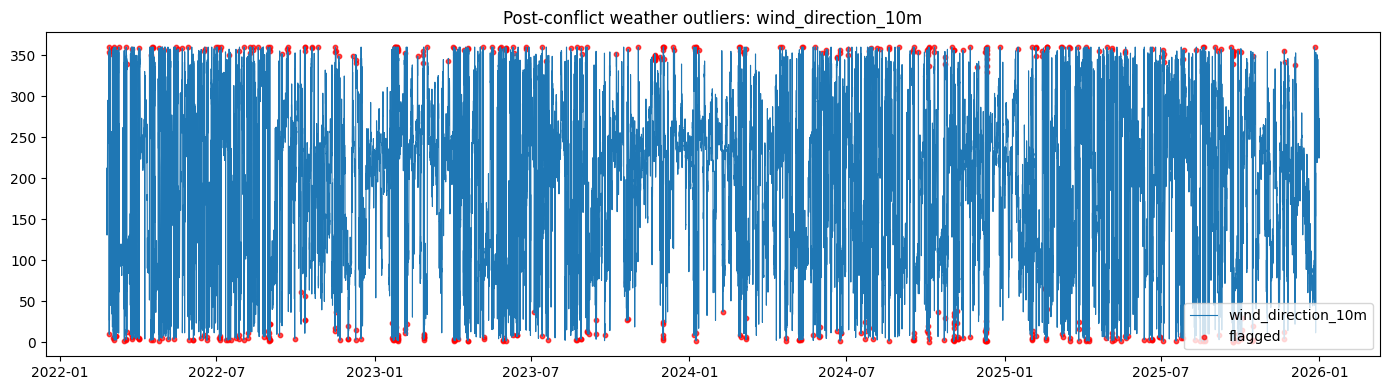

apparent_temperature (post-conflict)


,Column,Rows,Flagged,Flagged_%
8,apparent_temperature,33764,576,1.71


,timestamp,apparent_temperature,period
110630,2025-08-15 14:00:00,37.47,post_conflict
110629,2025-08-15 13:00:00,37.09,post_conflict
110631,2025-08-15 15:00:00,36.17,post_conflict
109575,2025-07-02 15:00:00,35.83,post_conflict
109574,2025-07-02 14:00:00,35.59,post_conflict
109166,2025-06-15 14:00:00,35.51,post_conflict
82960,2022-06-19 16:00:00,35.41,post_conflict
92344,2023-07-15 16:00:00,35.35,post_conflict


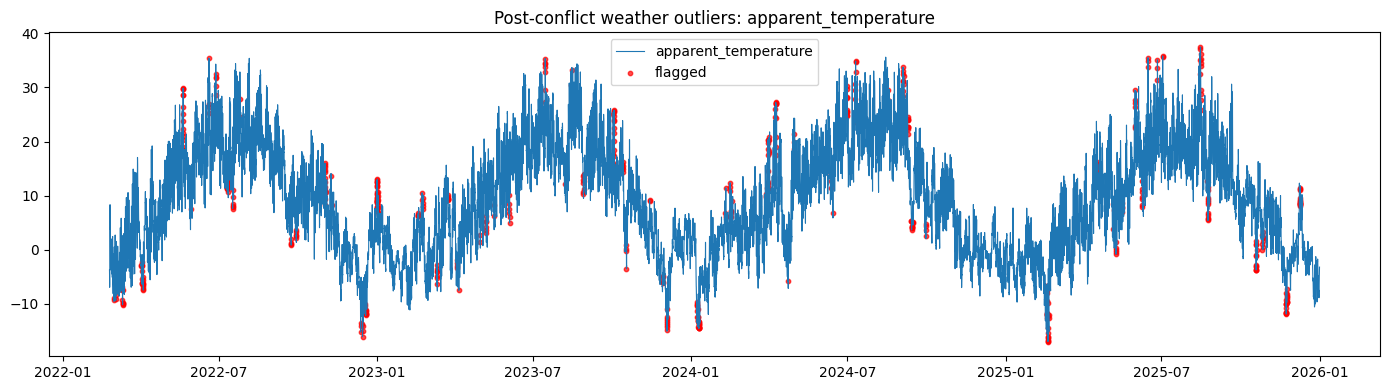

wind_gusts_10m (post-conflict)


,Column,Rows,Flagged,Flagged_%
9,wind_gusts_10m,33764,526,1.56


,timestamp,wind_gusts_10m,period
102590,2024-09-14 14:00:00,75.96,post_conflict
96181,2023-12-22 13:00:00,74.52,post_conflict
96180,2023-12-22 12:00:00,73.08,post_conflict
88456,2023-02-03 16:00:00,73.08,post_conflict
96161,2023-12-21 17:00:00,72.72,post_conflict
96160,2023-12-21 16:00:00,72.00,post_conflict
88454,2023-02-03 14:00:00,72.00,post_conflict
97261,2024-02-05 13:00:00,70.92,post_conflict


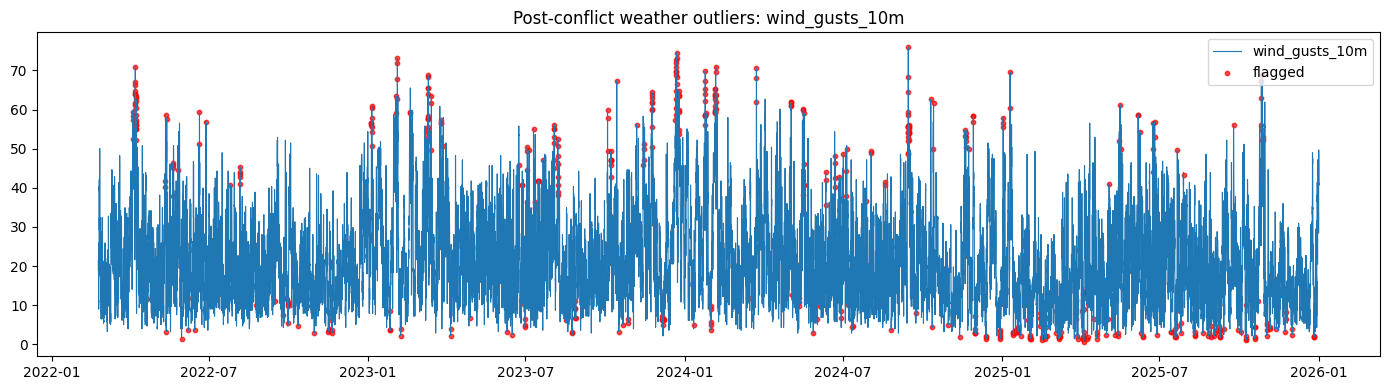

precipitation (post-conflict)


,Column,Rows,Flagged,Flagged_%
10,precipitation,33764,263,0.78


,timestamp,precipitation,period
84591,2022-08-26 15:00:00,15.20,post_conflict
92668,2023-07-29 04:00:00,12.40,post_conflict
92702,2023-07-30 14:00:00,9.90,post_conflict
83086,2022-06-24 22:00:00,9.40,post_conflict
93115,2023-08-16 19:00:00,8.60,post_conflict
109888,2025-07-15 16:00:00,8.50,post_conflict
101547,2024-08-02 03:00:00,7.30,post_conflict
101053,2024-07-12 13:00:00,7.20,post_conflict


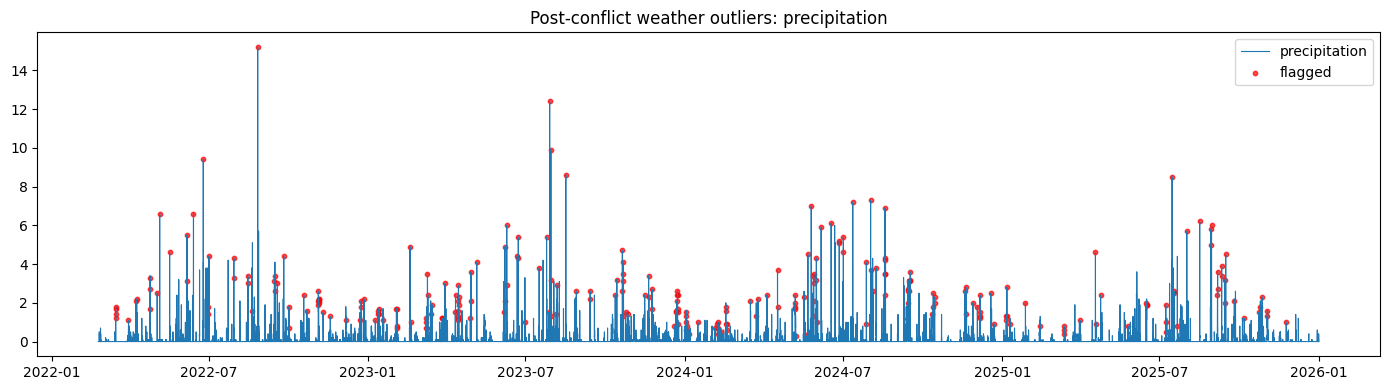

snowfall (post-conflict)


,Column,Rows,Flagged,Flagged_%
11,snowfall,33764,104,0.31


,timestamp,snowfall,period
104572,2024-12-06 04:00:00,1.61,post_conflict
96205,2023-12-23 13:00:00,1.26,post_conflict
88059,2023-01-18 03:00:00,1.19,post_conflict
96206,2023-12-23 14:00:00,1.12,post_conflict
96204,2023-12-23 12:00:00,1.05,post_conflict
104201,2024-11-20 17:00:00,1.05,post_conflict
89416,2023-03-15 16:00:00,0.91,post_conflict
106240,2025-02-13 16:00:00,0.91,post_conflict


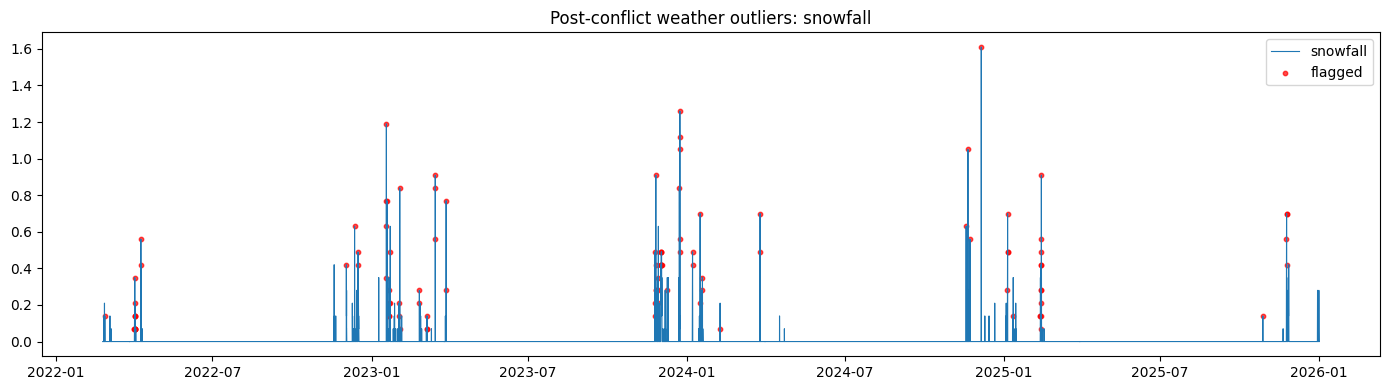

snow_depth (post-conflict)


,Column,Rows,Flagged,Flagged_%
12,snow_depth,33764,61,0.18


,timestamp,snow_depth,period
88307,2023-01-28 11:00:00,0.09,post_conflict
88314,2023-01-28 18:00:00,0.09,post_conflict
88305,2023-01-28 09:00:00,0.09,post_conflict
88309,2023-01-28 13:00:00,0.09,post_conflict
88310,2023-01-28 14:00:00,0.09,post_conflict
88311,2023-01-28 15:00:00,0.09,post_conflict
88312,2023-01-28 16:00:00,0.09,post_conflict
88313,2023-01-28 17:00:00,0.09,post_conflict


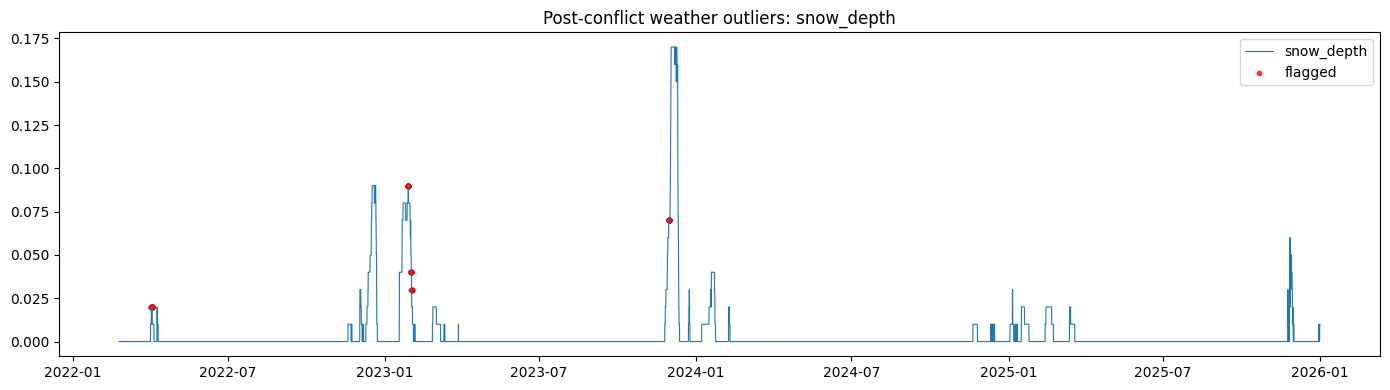

In [26]:
# After conflict - Weather outlier diagnostics (contextual by month/hour)
post_df = df_eda[df_eda["period"] == "post_conflict"].copy()

for col in WEATHER_VARIABLES:
    if col not in post_df.columns:
        continue
    s = pd.to_numeric(post_df[col], errors="coerce")
    lo = post_df.groupby(["month", "hour"])[col].transform(
        lambda x: pd.to_numeric(x, errors="coerce").quantile(0.005)
    )
    hi = post_df.groupby(["month", "hour"])[col].transform(
        lambda x: pd.to_numeric(x, errors="coerce").quantile(0.995)
    )
    post_df[f"{col}_flag_weather"] = (s < lo) | (s > hi)

summary_post_weather = summary_from_flags(post_df, WEATHER_VARIABLES, "flag_weather")

for col in WEATHER_VARIABLES:
    flag_col = f"{col}_flag_weather"
    if col not in post_df.columns or flag_col not in post_df.columns:
        continue

    print(f"{col} (post-conflict)")
    display(summary_post_weather[summary_post_weather["Column"] == col])
    display(top_flagged_rows(post_df, col, flag_col, n=8))

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(post_df[timestamp_col], post_df[col], linewidth=0.8, label=col)
    flagged = post_df[post_df[flag_col]]
    ax.scatter(
        flagged[timestamp_col],
        flagged[col],
        s=10,
        color="red",
        alpha=0.7,
        label="flagged",
    )
    ax.set_title(f"Post-conflict weather outliers: {col}")
    ax.legend()
    plt.tight_layout()
    plt.show()

Same as before conflict, all weather variables are withing range so that's good. There are no extreme outliers and all data looks good.

#### Price

traded_volume_mwh (post-conflict)
Daily-level summary:


,Column,Rows,Flagged,Flagged_%
0,traded_volume_mwh,1394,2,0.14


Hourly-mapped summary:


,Column,Rows,Flagged,Flagged_%
0,traded_volume_mwh,33456,48,0.14


,date,traded_volume_mwh
16944,2024-01-31,55829.20
16416,2024-01-09,54783.20


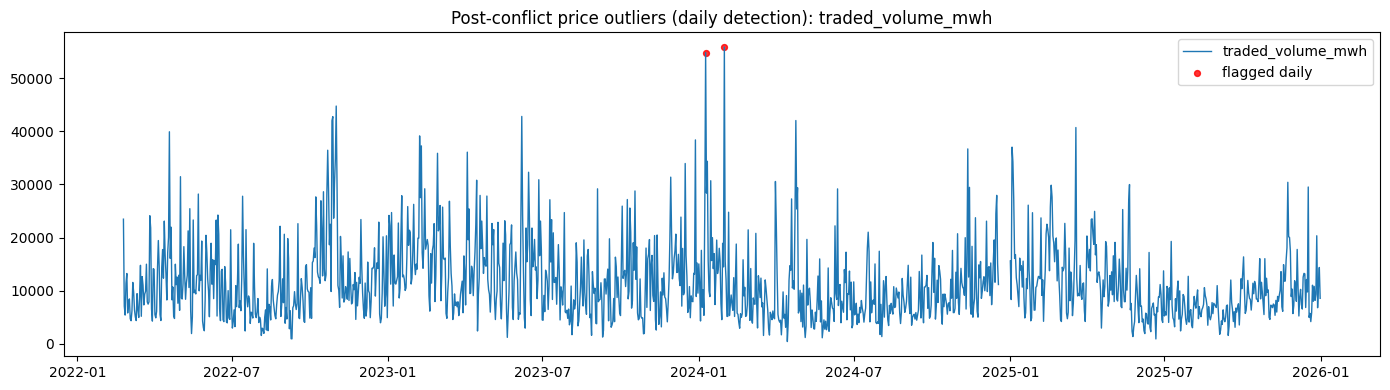

weighted_avg_price_eur_mwh (post-conflict)
Daily-level summary:


,Column,Rows,Flagged,Flagged_%
1,weighted_avg_price_eur_mwh,1394,161,11.55


Hourly-mapped summary:


,Column,Rows,Flagged,Flagged_%
1,weighted_avg_price_eur_mwh,33456,3864,11.55


,date,weighted_avg_price_eur_mwh
4392,2022-08-26,307.99
4368,2022-08-25,303.29
4344,2022-08-24,276.80
4416,2022-08-27,275.99
4296,2022-08-22,275.84
4320,2022-08-23,275.78
4488,2022-08-30,267.00
4464,2022-08-29,265.61
4440,2022-08-28,258.58
4512,2022-08-31,256.76


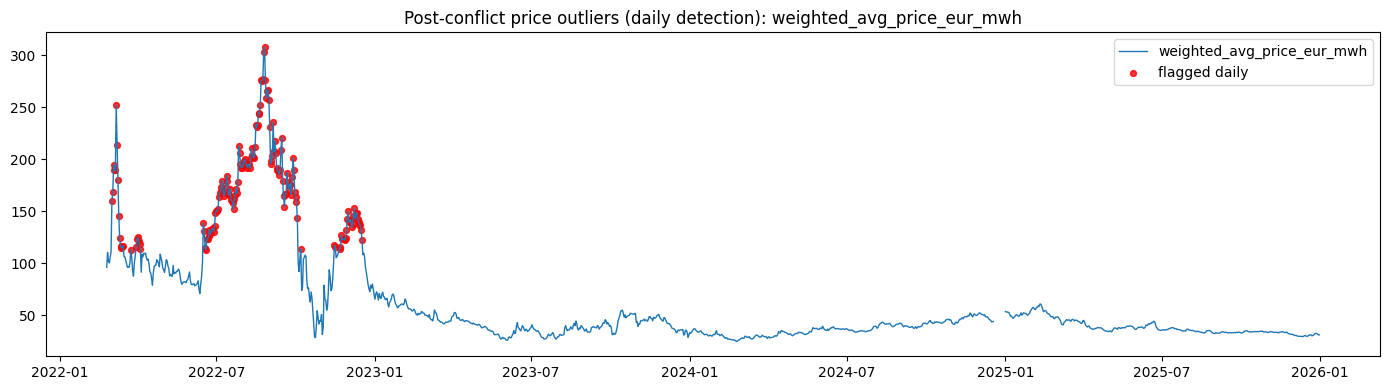

min_price_eur_mwh (post-conflict)
Daily-level summary:


,Column,Rows,Flagged,Flagged_%
2,min_price_eur_mwh,1394,161,11.55


Hourly-mapped summary:


,Column,Rows,Flagged,Flagged_%
2,min_price_eur_mwh,33456,3864,11.55


,date,min_price_eur_mwh
4392,2022-08-26,271.40
4368,2022-08-25,265.20
4344,2022-08-24,261.51
4320,2022-08-23,260.00
4296,2022-08-22,255.00
4488,2022-08-30,254.50
4416,2022-08-27,250.00
4464,2022-08-29,249.90
4272,2022-08-21,246.90
4224,2022-08-19,240.01


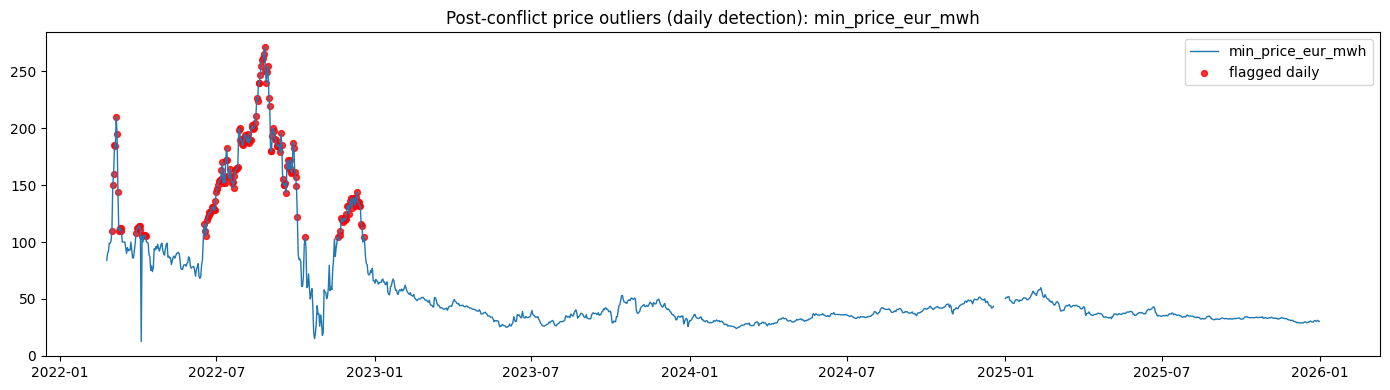

max_price_eur_mwh (post-conflict)
Daily-level summary:


,Column,Rows,Flagged,Flagged_%
3,max_price_eur_mwh,1394,175,12.55


Hourly-mapped summary:


,Column,Rows,Flagged,Flagged_%
3,max_price_eur_mwh,33456,4200,12.55


,date,max_price_eur_mwh
16968,2024-02-01,1500.00
4416,2022-08-27,320.50
4368,2022-08-25,319.70
4392,2022-08-26,317.00
4320,2022-08-23,310.00
4344,2022-08-24,296.00
4296,2022-08-22,295.00
4464,2022-08-29,290.00
4488,2022-08-30,286.43
264,2022-03-07,283.00


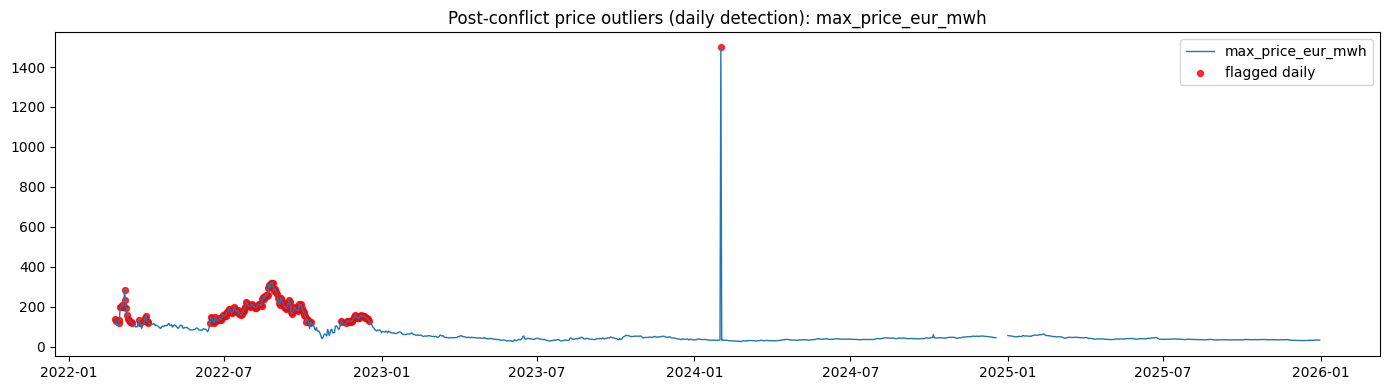

In [27]:
# After conflict - Price outlier diagnostics (daily first, then mapped back to hourly)
post_df = df_eda[df_eda["period"] == "post_conflict"].copy()
price_daily_frames = []

for col in PRICE_VARIABLES:
    if col not in post_df.columns:
        continue
    daily = post_df.groupby("date", as_index=False)[col].median()
    z = mad_zscore(daily[col])
    daily[f"{col}_flag_price_daily"] = z.abs() > 6
    price_daily_frames.append(daily[["date", f"{col}_flag_price_daily", col]])

if price_daily_frames:
    merged_daily = price_daily_frames[0]
    for d in price_daily_frames[1:]:
        merged_daily = merged_daily.merge(d, on="date", how="outer")

    for col in PRICE_VARIABLES:
        flag_col = f"{col}_flag_price_daily"
        if flag_col in merged_daily.columns:
            post_df = post_df.merge(
                merged_daily[["date", flag_col]], on="date", how="left"
            )
            post_df[flag_col] = post_df[flag_col].fillna(False)

summary_post_price_daily = summary_from_flags(
    post_df.drop_duplicates(subset=["date"]), PRICE_VARIABLES, "flag_price_daily"
)
summary_post_price_hourly = summary_from_flags(
    post_df, PRICE_VARIABLES, "flag_price_daily"
)

for col in PRICE_VARIABLES:
    flag_col = f"{col}_flag_price_daily"
    if col not in post_df.columns or flag_col not in post_df.columns:
        continue

    print(f"{col} (post-conflict)")
    print("Daily-level summary:")
    display(summary_post_price_daily[summary_post_price_daily["Column"] == col])
    print("Hourly-mapped summary:")
    display(summary_post_price_hourly[summary_post_price_hourly["Column"] == col])

    top_daily = (
        post_df.loc[post_df[flag_col], ["date", col]]
        .drop_duplicates(subset=["date"])
        .sort_values(col, key=lambda s: s.abs(), ascending=False)
        .head(10)
    )
    display(top_daily)

    price_plot = post_df.drop_duplicates(subset=["date"])[
        ["date", col, flag_col]
    ].copy()
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(price_plot["date"], price_plot[col], linewidth=1, label=col)
    flagged = price_plot[price_plot[flag_col]]
    ax.scatter(
        flagged["date"],
        flagged[col],
        s=18,
        color="red",
        alpha=0.8,
        label="flagged daily",
    )
    ax.set_title(f"Post-conflict price outliers (daily detection): {col}")
    ax.legend()
    plt.tight_layout()
    plt.show()

Besides that one extreme outlier right above this, most looks reasonable. As always we have zero values.

# Summary 🧾

This notebook was used to identify data-quality issues and define fixed cleaning rules implemented in `src/preprocessing` (not in this notebook). The final preprocessing strategy is:

- **Weather variables** 🌦️: keep as-is except missing values (`NaN`), which are filled. No weather outlier filtering is applied.
- **Consumption and price**: treat invalid values as missing and then fill continuously over the full timeline.
- **Invalid values to mask/drop** (non-weather):
  - `NaN` values
  - zero values (according to variable rules below)
  - negative values where not physically meaningful (consumption and price)
- **Price granularity rule** 💶: price is a **daily value replicated to 24 hourly rows**. All price cleaning/filling is done at daily level and then broadcast back to hourly rows.

## Hand-picked measurement-error thresholds 🎯 (used globally, not pre/post conflict splitting)

- **Consumption components** (`gasnet`, `jmpnet`, `smpnet`, `vcpnet`): values `> 800 000` are invalid.
  - **gasnet** before war the earliest not outlier value is *644 837* and after is *696 610*
  - **jmpnet** before war the earliest not outlier value is *691 011* and after is *517 464*
  - **smpnet** before war the earliest not outlier value is *476 589* and after is *412 861*
  - **vcpnet** before war the earliest not outlier value is *410 001* and after is *259 441*
  - so **800 000** should be sufficiently high to cover any future extreme values while still removing the clear outliers
- **Price**:
  - `traded_volume_mwh`: do not apply additional upper-threshold dropping
  - `weighted_avg_price_eur_mwh`: do not apply additional upper-threshold dropping
  - `min_price_eur_mwh`: no extra upper-threshold dropping
  - `max_price_eur_mwh`: values `> 500` are invalid (*200* before and *320* after conflict, **500** should be sufficiently high to cover any future extreme values while still removing the clear outlier)

## Consumption total consistency

- `consumption_total` is derived from component consumption columns.
- If any component value is masked/changed, the corresponding `consumption_total` row is also invalidated and then recomputed as the sum of cleaned components.

## Filling strategy 🔄

- After masking invalid values, data is filled **continuously from start to end** of the timeline.
- Because missing/invalid points can occur in blocks, filling uses context from neighboring rows and sibling columns in the same category to improve stability.

## Execution note ▶️

- Preprocessing is run from `src/preprocessing` (not from repository root) using `run_preprocessing.py`.